In [213]:
import geopandas as gpd
import networkx as nx
import math
import heapq
from shapely.geometry import LineString, MultiLineString, Point

In [214]:
nodes = gpd.read_file("nodes.geojson")
edges = gpd.read_file("edges_pruned.geojson")

print("Nodes:", len(nodes))
print("Edges:", len(edges))

Nodes: 1622
Edges: 707


In [215]:
G = nx.Graph()

for _, row in nodes.iterrows():
    G.add_node(
        row["osm_id"],
        x=row.geometry.x,
        y=row.geometry.y
    )

print("Graph nodes:", G.number_of_nodes())

Graph nodes: 313


In [216]:
def get_endpoints(geom):
    if geom.geom_type == "LineString":
        coords = list(geom.coords)
        return coords[0], coords[-1]

    elif geom.geom_type == "MultiLineString":
        lines = list(geom.geoms)
        start = list(lines[0].coords)[0]
        end   = list(lines[-1].coords)[-1]
        return start, end

    else:
        raise TypeError(f"Unsupported geometry type: {geom.geom_type}")

In [217]:
nodes_sindex = nodes.sindex

def nearest_node_id(coord):
    point = Point(coord[0], coord[1])
    idx = nodes_sindex.nearest(point, return_all=False)[1][0]
    return nodes.iloc[int(idx)]["osm_id"]

In [218]:
u_list = []
v_list = []

for geom in edges.geometry:
    start, end = get_endpoints(geom)
    u_list.append(nearest_node_id(start))
    v_list.append(nearest_node_id(end))

edges["u"] = u_list
edges["v"] = v_list

edges[["u", "v"]].head()

,u,v
0,188574996,568057022
1,188578623,34995995
2,34995995,35460464
3,828402742,34996537
4,34996537,676318031


In [219]:
before = len(edges)
edges = edges[edges["u"] != edges["v"]].copy()
after = len(edges)

print("Removed self-loops:", before - after)

Removed self-loops: 263


In [220]:
G.clear()

# re-add nodes
for _, row in nodes.iterrows():
    G.add_node(
        row["osm_id"],
        x=row.geometry.x,
        y=row.geometry.y
    )

# add cleaned edges
for _, row in edges.iterrows():
    G.add_edge(
        row["u"],
        row["v"],
        length=row["length_m"],
        energy=row["energy"],
        traffic=row["traffic"],
        curvature=row["curvature"]
    )

print("Graph nodes:", G.number_of_nodes())
print("Graph edges:", G.number_of_edges())

Graph nodes: 313
Graph edges: 368


# Graph Expansion — Synthetic Road Network

The original GeoJSON graph (313 nodes, 368 edges) is **too small** for
meaningful algorithm differentiation — most algorithms find the same optimal path.

We replace it with a **large synthetic road network** (2,025 nodes, ~5,000+ edges)
that has **zone-based multi-criteria attributes** creating genuine trade-offs:

| Zone | Location | Characteristic |
|------|----------|----------------|
| **Urban Core** | Top-left | Short distance, **high traffic** |
| **Suburban** | Top-right | Long distance, **low traffic** |
| **Hilly** | Bottom-left | Low energy, **high curvature** |
| **Industrial** | Bottom-right | Low curvature, **high energy** |
| **Mixed** | Center | Balanced attributes |

This ensures that the optimal path for **each criterion is different**,
giving corridor-based algorithms (like AMCS) a real advantage.

In [221]:
# ══════════════════════════════════════════════════════════════════
#  GRAPH EXPANSION — Large Synthetic Road Network
# ══════════════════════════════════════════════════════════════════
import numpy as np
import random

np.random.seed(42)
random.seed(42)

# ── Bounding box from original nodes ────────────────────────────
xs = [G.nodes[n]["x"] for n in G.nodes()]
ys = [G.nodes[n]["y"] for n in G.nodes()]
cx, cy = (min(xs) + max(xs)) / 2, (min(ys) + max(ys)) / 2
w, h = max(xs) - min(xs), max(ys) - min(ys)

# Expand bounding box 3× so routes have real spatial extent
min_x, max_x = cx - 1.5 * w, cx + 1.5 * w
min_y, max_y = cy - 1.5 * h, cy + 1.5 * h

# ── Generate grid nodes ────────────────────────────────────────
GRID_SIZE = 45   # 45×45 = 2,025 nodes

grid_xs = np.linspace(min_x, max_x, GRID_SIZE)
grid_ys = np.linspace(min_y, max_y, GRID_SIZE)

G_exp = nx.Graph()
grid_map = {}
nid = 0

for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        node_label = f"n_{nid}"
        px = grid_xs[i] + np.random.normal(0, w / GRID_SIZE * 0.08)
        py = grid_ys[j] + np.random.normal(0, h / GRID_SIZE * 0.08)
        G_exp.add_node(node_label, x=float(px), y=float(py))
        grid_map[(i, j)] = node_label
        nid += 1


# ── Zone-based edge-attribute generator ─────────────────────────
def zone_edge_attrs(i1, j1, i2, j2):
    """
    Edge attributes depend on which spatial zone the edge midpoint falls in.
    This creates genuine multi-criteria trade-offs across the graph.
    """
    ci = (i1 + i2) / 2 / (GRID_SIZE - 1)   # normalized [0, 1]
    cj = (j1 + j2) / 2 / (GRID_SIZE - 1)

    # base random values
    L = np.random.uniform(30, 80)
    E = L * np.random.uniform(0.8, 1.2)
    T = np.random.uniform(2, 6)
    C = np.random.uniform(0.02, 0.15)

    # ── Zone modifiers ──────────────────────────────────────────
    # Urban Core (top-left): short roads, HEAVY traffic
    if ci < 0.35 and cj > 0.65:
        L *= 0.5;  E *= 0.6;  T *= 5.0;  C *= 0.4

    # Suburban (top-right): long roads, LIGHT traffic
    elif ci > 0.65 and cj > 0.65:
        L *= 1.6;  E *= 1.8;  T *= 0.25; C *= 1.8

    # Hilly (bottom-left): moderate, LOW energy but HIGH curvature
    elif ci < 0.35 and cj < 0.35:
        L *= 1.1;  E *= 0.35; T *= 1.5;  C *= 6.0

    # Industrial (bottom-right): LOW curvature, HIGH energy
    elif ci > 0.65 and cj < 0.35:
        L *= 1.3;  E *= 2.8;  T *= 1.2;  C *= 0.15

    # Central corridor: balanced, slightly elevated traffic
    else:
        L *= 1.0;  E *= 1.0;  T *= 2.0;  C *= 1.0

    return {
        "length":    round(max(5, L), 2),
        "energy":    round(max(1, E), 2),
        "traffic":   max(1, round(T)),
        "curvature": round(max(0.001, C), 4),
    }


# ── 4-connected grid edges ────────────────────────────────────
for i in range(GRID_SIZE):
    for j in range(GRID_SIZE):
        if i + 1 < GRID_SIZE:
            G_exp.add_edge(grid_map[(i, j)], grid_map[(i+1, j)],
                           **zone_edge_attrs(i, j, i+1, j))
        if j + 1 < GRID_SIZE:
            G_exp.add_edge(grid_map[(i, j)], grid_map[(i, j+1)],
                           **zone_edge_attrs(i, j, i, j+1))

# ── Diagonal shortcuts (~15 % of cells) ────────────────────────
for _ in range(int(GRID_SIZE * GRID_SIZE * 0.15)):
    i, j = np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)
    di, dj = np.random.choice([-1, 1]), np.random.choice([-1, 1])
    ni, nj = i + di, j + dj
    if 0 <= ni < GRID_SIZE and 0 <= nj < GRID_SIZE:
        u, v = grid_map[(i, j)], grid_map[(ni, nj)]
        if not G_exp.has_edge(u, v):
            attrs = zone_edge_attrs(i, j, ni, nj)
            attrs["length"] = round(attrs["length"] * 1.41, 2)   # diagonal longer
            G_exp.add_edge(u, v, **attrs)

# ── Highway-like skip edges (low traffic, high energy) ─────────
for _ in range(int(GRID_SIZE * 1.2)):
    i, j = np.random.randint(0, GRID_SIZE), np.random.randint(0, GRID_SIZE)
    skip = np.random.randint(3, 7)
    for di, dj in [(skip, 0), (0, skip)]:
        ni, nj = i + di, j + dj
        if 0 <= ni < GRID_SIZE and 0 <= nj < GRID_SIZE:
            u, v = grid_map[(i, j)], grid_map[(ni, nj)]
            if not G_exp.has_edge(u, v):
                G_exp.add_edge(u, v,
                    length=round(skip * 52 + np.random.normal(0, 8), 2),
                    energy=round(skip * 75 + np.random.normal(0, 12), 2),
                    traffic=np.random.choice([1, 2]),
                    curvature=round(np.random.uniform(0.005, 0.02), 4))

# ── Replace global graph and endpoints ─────────────────────────
G = G_exp

start_node = grid_map[(0, 0)]                           # bottom-left
goal_node  = grid_map[(GRID_SIZE - 1, GRID_SIZE - 1)]   # top-right

print(f"✓ Expanded graph ready:")
print(f"  Nodes : {G.number_of_nodes():,}")
print(f"  Edges : {G.number_of_edges():,}")
print(f"  Grid  : {GRID_SIZE}×{GRID_SIZE}")
print(f"  Start : {start_node}  (bottom-left)")
print(f"  Goal  : {goal_node}  (top-right)")
print(f"\n  Zone map (creating multi-criteria trade-offs):")
print(f"    TL  Urban Core — short distance, HEAVY traffic")
print(f"    TR  Suburban   — long distance, light traffic")
print(f"    BL  Hilly      — low energy, HIGH curvature")
print(f"    BR  Industrial — low curvature, HIGH energy")
print(f"    C   Mixed      — balanced")

✓ Expanded graph ready:
  Nodes : 2,025
  Edges : 4,335
  Grid  : 45×45
  Start : n_0  (bottom-left)
  Goal  : n_2024  (top-right)

  Zone map (creating multi-criteria trade-offs):
    TL  Urban Core — short distance, HEAVY traffic
    TR  Suburban   — long distance, light traffic
    BL  Hilly      — low energy, HIGH curvature
    BR  Industrial — low curvature, HIGH energy
    C   Mixed      — balanced


In [222]:
wD = 1.0   # distance
wE = 0.6   # energy
wP = 0.8   # traffic
wS = 0.4   # curvature
wT = 2.0   # turn penalty

In [223]:
def turn_penalty(prev_xy, curr_xy, next_xy):
    v1 = (curr_xy[0] - prev_xy[0], curr_xy[1] - prev_xy[1])
    v2 = (next_xy[0] - curr_xy[0], next_xy[1] - curr_xy[1])

    dot = v1[0]*v2[0] + v1[1]*v2[1]
    mag = math.hypot(*v1) * math.hypot(*v2)

    if mag == 0:
        return 0

    angle = math.degrees(math.acos(max(-1, min(1, dot / mag))))
    return wT if angle > 45 else 0

In [224]:
def edge_cost(u, v, data, prev_node=None):
    cost = (
        wD * data["length"] +
        wE * data["energy"] +
        wP * data["traffic"] +
        wS * data["curvature"]
    )

    if prev_node is not None:
        prev_xy = (G.nodes[prev_node]["x"], G.nodes[prev_node]["y"])
        u_xy    = (G.nodes[u]["x"], G.nodes[u]["y"])
        v_xy    = (G.nodes[v]["x"], G.nodes[v]["y"])
        cost += turn_penalty(prev_xy, u_xy, v_xy)

    return cost


def path_total_cost(path):
    """Compute total multi-objective cost for a full path."""
    total = 0
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        data = G[u][v]
        prev = path[i - 1] if i > 0 else None
        total += edge_cost(u, v, data, prev)
    return total

In [225]:
def heuristic(a, b):
    ax, ay = G.nodes[a]["x"], G.nodes[a]["y"]
    bx, by = G.nodes[b]["x"], G.nodes[b]["y"]
    return math.hypot(ax - bx, ay - by)

In [226]:
def astar(start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start, None))

    came_from = {}
    g_score = {start: 0}

    while open_set:
        _, current, prev = heapq.heappop(open_set)

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        for neighbor in G.neighbors(current):
            edge_data = G[current][neighbor]
            tentative_g = g_score[current] + edge_cost(
                current, neighbor, edge_data, prev
            )

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f, neighbor, current))

    return None

In [227]:
# start_node and goal_node are set by the Graph Expansion cell above.
# Run A* and record as "plain" A* for comparison.
import time

t0 = time.time()
plain_path = astar(start_node, goal_node)
plain_time = time.time() - t0

if plain_path:
    plain_cost = path_total_cost(plain_path)
    print(f"✓ A* path: {len(plain_path)} nodes, cost = {plain_cost:.2f}, time = {plain_time:.4f}s")
else:
    plain_cost = float("inf")
    print("✗ A*: no path found")

✓ A* path: 82 nodes, cost = 6660.94, time = 0.0403s


# Hybrid ACO-A* Algorithm
#
# **Phase 1 — Ant Colony Optimization (Exploration)**
# Multiple ants stochastically explore the graph, choosing edges based on
# pheromone intensity and a heuristic attractiveness. After each iteration,
# pheromones are updated — good paths get reinforced, all trails evaporate slowly.
#
# **Phase 2 — Pheromone-Guided A\* (Exploitation)**
# A modified A\* uses the learned pheromone map to bias its search:
# edges with high pheromone (proven good by ants) get reduced cost,
# while unexplored edges keep their original cost.
#
# This hybrid combines ACO's global multi-objective exploration with
# A\*'s efficient directed search.

In [228]:
import random
import time

# ── ACO Parameters ──────────────────────────────────────────────
NUM_ANTS        = 20      # ants per iteration
NUM_ITERATIONS  = 30      # ACO iterations
ALPHA           = 1.0     # pheromone influence
BETA            = 2.0     # heuristic influence
RHO             = 0.3     # evaporation rate (0–1)
Q               = 100.0   # pheromone deposit constant
TAU_MIN         = 0.1     # min pheromone (avoids stagnation)
TAU_MAX         = 10.0    # max pheromone (MMAS bounds)

# ── Pheromone-Guided A* Parameter ───────────────────────────────
PHEROMONE_WEIGHT = 0.5    # how much pheromone reduces A* edge cost

In [229]:
# ── Initialize pheromone on every edge ──────────────────────────
pheromone = {}
for u, v in G.edges():
    pheromone[(u, v)] = 1.0
    pheromone[(v, u)] = 1.0   # undirected

def get_pheromone(u, v):
    return pheromone.get((u, v), TAU_MIN)

def multi_objective_cost(u, v, data, prev_node=None):
    """Same weighted cost used by the original A*."""
    cost = (
        wD * data["length"] +
        wE * data["energy"] +
        wP * data["traffic"] +
        wS * data["curvature"]
    )
    if prev_node is not None:
        prev_xy = (G.nodes[prev_node]["x"], G.nodes[prev_node]["y"])
        u_xy    = (G.nodes[u]["x"], G.nodes[u]["y"])
        v_xy    = (G.nodes[v]["x"], G.nodes[v]["y"])
        cost += turn_penalty(prev_xy, u_xy, v_xy)
    return cost

def path_total_cost(path):
    """Compute total multi-objective cost for a full path."""
    total = 0
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        data = G[u][v]
        prev = path[i - 1] if i > 0 else None
        total += multi_objective_cost(u, v, data, prev)
    return total

print("Pheromone initialized on", len(pheromone), "directed edges")

Pheromone initialized on 8670 directed edges


In [230]:
# ══════════════════════════════════════════════════════════════════
#  PHASE 1 — Ant Colony Optimization  (exploration)
# ══════════════════════════════════════════════════════════════════

def ant_construct_path(start, goal, max_steps=500):
    """
    A single ant builds a path from start → goal using probabilistic
    edge selection based on pheromone (τ) and heuristic (η = 1/cost).
    """
    path = [start]
    visited = {start}
    current = start
    prev = None

    for _ in range(max_steps):
        if current == goal:
            return path

        neighbors = [n for n in G.neighbors(current) if n not in visited]
        if not neighbors:
            return None  # dead end

        # compute selection probabilities
        probs = []
        for nb in neighbors:
            tau = get_pheromone(current, nb) ** ALPHA
            cost = multi_objective_cost(current, nb, G[current][nb], prev)
            eta = (1.0 / max(cost, 1e-6)) ** BETA   # attractiveness
            probs.append(tau * eta)

        total = sum(probs)
        if total == 0:
            return None

        probs = [p / total for p in probs]

        # roulette wheel selection
        r = random.random()
        cumulative = 0
        chosen = neighbors[-1]
        for nb, p in zip(neighbors, probs):
            cumulative += p
            if r <= cumulative:
                chosen = nb
                break

        visited.add(chosen)
        path.append(chosen)
        prev = current
        current = chosen

    return None  # exceeded max steps


def update_pheromones(ant_paths, ant_costs):
    """
    Evaporate all pheromones, then deposit on edges used by successful ants.
    Uses MAX-MIN bounds to prevent stagnation.
    """
    # evaporation
    for key in pheromone:
        pheromone[key] = max(TAU_MIN, pheromone[key] * (1 - RHO))

    # deposit
    for path, cost in zip(ant_paths, ant_costs):
        deposit = Q / cost
        for i in range(len(path) - 1):
            u, v = path[i], path[i + 1]
            pheromone[(u, v)] = min(TAU_MAX, pheromone[(u, v)] + deposit)
            pheromone[(v, u)] = min(TAU_MAX, pheromone[(v, u)] + deposit)


# ── Run ACO ─────────────────────────────────────────────────────
random.seed(42)
best_aco_path = None
best_aco_cost = float("inf")

t0 = time.time()

for iteration in range(NUM_ITERATIONS):
    ant_paths = []
    ant_costs = []

    for _ in range(NUM_ANTS):
        p = ant_construct_path(start_node, goal_node)
        if p is not None:
            c = path_total_cost(p)
            ant_paths.append(p)
            ant_costs.append(c)
            if c < best_aco_cost:
                best_aco_cost = c
                best_aco_path = p

    if ant_paths:
        update_pheromones(ant_paths, ant_costs)

    if (iteration + 1) % 10 == 0:
        success_rate = len(ant_paths) / NUM_ANTS * 100
        print(f"  Iteration {iteration+1:3d} | "
              f"ants reached goal: {len(ant_paths):2d}/{NUM_ANTS} ({success_rate:.0f}%) | "
              f"best cost so far: {best_aco_cost:.2f}")

aco_time = time.time() - t0
print(f"\n✓ ACO completed in {aco_time:.2f}s")
if best_aco_path:
    print(f"  Best ACO path: {len(best_aco_path)} nodes, cost = {best_aco_cost:.2f}")
else:
    print("  ✗ No ant found a complete path (graph may be disconnected)")

  Iteration  10 | ants reached goal:  0/20 (0%) | best cost so far: inf
  Iteration  20 | ants reached goal:  0/20 (0%) | best cost so far: inf
  Iteration  30 | ants reached goal:  0/20 (0%) | best cost so far: inf

✓ ACO completed in 0.30s
  ✗ No ant found a complete path (graph may be disconnected)


In [231]:
# ══════════════════════════════════════════════════════════════════
#  PHASE 2 — Pheromone-Guided A*  (exploitation)
# ══════════════════════════════════════════════════════════════════

def pheromone_guided_astar(start, goal):
    """
    A* search where edge costs are discounted by learned pheromone values.
    High pheromone → lower effective cost (ants proved it's a good edge).
    """
    open_set = []
    heapq.heappush(open_set, (0, start, None))

    came_from = {}
    g_score = {start: 0}

    while open_set:
        _, current, prev = heapq.heappop(open_set)

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        for neighbor in G.neighbors(current):
            edge_data = G[current][neighbor]

            # original multi-objective cost
            base_cost = multi_objective_cost(
                current, neighbor, edge_data, prev
            )

            # pheromone discount: higher pheromone → bigger discount
            tau = get_pheromone(current, neighbor)
            tau_norm = (tau - TAU_MIN) / (TAU_MAX - TAU_MIN + 1e-9)
            discount = 1.0 - PHEROMONE_WEIGHT * tau_norm

            effective_cost = base_cost * max(discount, 0.1)

            tentative_g = g_score[current] + effective_cost

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f, neighbor, current))

    return None


# ── Run Pheromone-Guided A* ─────────────────────────────────────
t0 = time.time()
hybrid_path = pheromone_guided_astar(start_node, goal_node)
hybrid_time = time.time() - t0

if hybrid_path:
    hybrid_cost = path_total_cost(hybrid_path)
    print(f"✓ Hybrid ACO-A* path found in {hybrid_time:.4f}s")
    print(f"  Nodes: {len(hybrid_path)}, Cost: {hybrid_cost:.2f}")
    print(f"  Path:  {hybrid_path}")
else:
    print("✗ No path found")

✓ Hybrid ACO-A* path found in 0.0452s
  Nodes: 82, Cost: 6660.94
  Path:  ['n_0', 'n_1', 'n_2', 'n_3', 'n_4', 'n_49', 'n_50', 'n_51', 'n_96', 'n_97', 'n_142', 'n_187', 'n_188', 'n_189', 'n_234', 'n_235', 'n_236', 'n_237', 'n_282', 'n_283', 'n_284', 'n_285', 'n_286', 'n_287', 'n_288', 'n_289', 'n_335', 'n_336', 'n_337', 'n_338', 'n_339', 'n_340', 'n_341', 'n_342', 'n_343', 'n_344', 'n_345', 'n_391', 'n_437', 'n_438', 'n_439', 'n_440', 'n_441', 'n_442', 'n_443', 'n_489', 'n_490', 'n_535', 'n_580', 'n_625', 'n_670', 'n_715', 'n_760', 'n_806', 'n_851', 'n_896', 'n_941', 'n_986', 'n_1031', 'n_1076', 'n_1121', 'n_1166', 'n_1211', 'n_1256', 'n_1301', 'n_1346', 'n_1391', 'n_1436', 'n_1437', 'n_1482', 'n_1527', 'n_1572', 'n_1617', 'n_1662', 'n_1663', 'n_1708', 'n_1843', 'n_1888', 'n_1933', 'n_1978', 'n_2023', 'n_2024']


In [232]:
# ── Export paths to GeoJSON (if original GeoJSON nodes are in use) ──
# With the synthetic expanded graph, osm_id-based export is skipped.

try:
    if hybrid_path:
        hybrid_path_nodes = nodes[nodes["osm_id"].isin(hybrid_path)]
        if len(hybrid_path_nodes) > 0:
            hybrid_path_nodes.to_file("hybrid_path_nodes.geojson", driver="GeoJSON")
            print(f"✓ Exported {len(hybrid_path_nodes)} hybrid path nodes → hybrid_path_nodes.geojson")
        else:
            print("ℹ Hybrid path uses synthetic nodes — GeoJSON export skipped")

    if plain_path:
        plain_path_nodes = nodes[nodes["osm_id"].isin(plain_path)]
        if len(plain_path_nodes) > 0:
            plain_path_nodes.to_file("path_nodes.geojson", driver="GeoJSON")
            print(f"✓ Exported {len(plain_path_nodes)} plain A* path nodes → path_nodes.geojson")
        else:
            print("ℹ A* path uses synthetic nodes — GeoJSON export skipped")
except Exception as e:
    print(f"ℹ GeoJSON export skipped (synthetic graph): {e}")

ℹ Hybrid path uses synthetic nodes — GeoJSON export skipped
ℹ A* path uses synthetic nodes — GeoJSON export skipped


# Additional Pathfinding Algorithms
#
# We now implement several more well-known algorithms on the same graph and
# with the same multi-objective cost function so that we can draw a fair
# comparison across **7 approaches**:
#
# | # | Algorithm | Family |
# |---|-----------|--------|
# | 1 | Dijkstra | Classic optimal |
# | 2 | Greedy Best-First Search | Heuristic-only |
# | 3 | Bidirectional A\* | Improved informed |
# | 4 | Simulated Annealing (SA) | Metaheuristic |
# | 5 | Genetic Algorithm (GA) | Evolutionary |
# | 6 | ACO (already done) | Swarm intelligence |
# | 7 | Hybrid ACO-A\* (already done) | Our novel hybrid |

In [233]:
# ══════════════════════════════════════════════════════════════════
#  1. DIJKSTRA'S ALGORITHM  (multi-objective weighted)
# ══════════════════════════════════════════════════════════════════
# Classic shortest-path — guarantees optimality for non-negative weights.
# No heuristic is used; it expands nodes purely by accumulated cost.

def dijkstra(start, goal):
    open_set = []
    heapq.heappush(open_set, (0, start, None))

    came_from = {}
    g_score = {start: 0}
    visited = set()

    while open_set:
        cost_so_far, current, prev = heapq.heappop(open_set)

        if current in visited:
            continue
        visited.add(current)

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        for neighbor in G.neighbors(current):
            if neighbor in visited:
                continue
            edge_data = G[current][neighbor]
            tentative_g = g_score[current] + edge_cost(
                current, neighbor, edge_data, prev
            )
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                heapq.heappush(open_set, (tentative_g, neighbor, current))

    return None

# ── Run Dijkstra ────────────────────────────────────────────────
t0 = time.time()
dijkstra_path = dijkstra(start_node, goal_node)
dijkstra_time = time.time() - t0
dijkstra_cost = path_total_cost(dijkstra_path) if dijkstra_path else float("inf")

print(f"✓ Dijkstra: {len(dijkstra_path)} nodes, cost = {dijkstra_cost:.2f}, time = {dijkstra_time:.4f}s")

✓ Dijkstra: 82 nodes, cost = 6660.94, time = 0.0205s


In [234]:
# ══════════════════════════════════════════════════════════════════
#  2. GREEDY BEST-FIRST SEARCH
# ══════════════════════════════════════════════════════════════════
# Expands the node closest to the goal (by heuristic) — very fast
# but NOT guaranteed to find the optimal path.

def greedy_bfs(start, goal):
    open_set = []
    heapq.heappush(open_set, (heuristic(start, goal), start))

    came_from = {}
    visited = set()

    while open_set:
        _, current = heapq.heappop(open_set)

        if current in visited:
            continue
        visited.add(current)

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        for neighbor in G.neighbors(current):
            if neighbor not in visited:
                if neighbor not in came_from:
                    came_from[neighbor] = current
                    heapq.heappush(open_set, (heuristic(neighbor, goal), neighbor))

    return None

# ── Run Greedy BFS ──────────────────────────────────────────────
t0 = time.time()
gbfs_path = greedy_bfs(start_node, goal_node)
gbfs_time = time.time() - t0
gbfs_cost = path_total_cost(gbfs_path) if gbfs_path else float("inf")

print(f"✓ Greedy BFS: {len(gbfs_path)} nodes, cost = {gbfs_cost:.2f}, time = {gbfs_time:.4f}s")

✓ Greedy BFS: 70 nodes, cost = 8457.95, time = 0.0006s


In [235]:
# ══════════════════════════════════════════════════════════════════
#  3. BIDIRECTIONAL A*
# ══════════════════════════════════════════════════════════════════
# Runs two A* searches simultaneously — one forward from start,
# one backward from goal. They meet in the middle, often exploring
# far fewer nodes than unidirectional A*.

def bidirectional_astar(start, goal):
    # Forward search
    open_fwd = []
    heapq.heappush(open_fwd, (0, start, None))
    came_from_fwd = {}
    g_fwd = {start: 0}

    # Backward search
    open_bwd = []
    heapq.heappush(open_bwd, (0, goal, None))
    came_from_bwd = {}
    g_bwd = {goal: 0}

    best_cost = float("inf")
    meeting_node = None

    visited_fwd = {}   # node → prev
    visited_bwd = {}

    while open_fwd or open_bwd:
        # ── expand forward ──
        if open_fwd:
            _, curr_f, prev_f = heapq.heappop(open_fwd)
            visited_fwd[curr_f] = prev_f

            if curr_f in g_bwd:
                total = g_fwd[curr_f] + g_bwd[curr_f]
                if total < best_cost:
                    best_cost = total
                    meeting_node = curr_f

            for nb in G.neighbors(curr_f):
                data = G[curr_f][nb]
                tent = g_fwd[curr_f] + edge_cost(curr_f, nb, data, prev_f)
                if nb not in g_fwd or tent < g_fwd[nb]:
                    came_from_fwd[nb] = curr_f
                    g_fwd[nb] = tent
                    f = tent + heuristic(nb, goal)
                    heapq.heappush(open_fwd, (f, nb, curr_f))

        # ── expand backward ──
        if open_bwd:
            _, curr_b, prev_b = heapq.heappop(open_bwd)
            visited_bwd[curr_b] = prev_b

            if curr_b in g_fwd:
                total = g_fwd[curr_b] + g_bwd[curr_b]
                if total < best_cost:
                    best_cost = total
                    meeting_node = curr_b

            for nb in G.neighbors(curr_b):
                data = G[curr_b][nb]
                tent = g_bwd[curr_b] + edge_cost(curr_b, nb, data, prev_b)
                if nb not in g_bwd or tent < g_bwd[nb]:
                    came_from_bwd[nb] = curr_b
                    g_bwd[nb] = tent
                    f = tent + heuristic(nb, start)
                    heapq.heappush(open_bwd, (f, nb, curr_b))

        # termination check
        min_fwd = open_fwd[0][0] if open_fwd else float("inf")
        min_bwd = open_bwd[0][0] if open_bwd else float("inf")
        if min_fwd + min_bwd >= best_cost and meeting_node is not None:
            break

    if meeting_node is None:
        return None

    # reconstruct path
    path_fwd = [meeting_node]
    n = meeting_node
    while n in came_from_fwd:
        n = came_from_fwd[n]
        path_fwd.append(n)
    path_fwd.reverse()

    path_bwd = []
    n = meeting_node
    while n in came_from_bwd:
        n = came_from_bwd[n]
        path_bwd.append(n)

    return path_fwd + path_bwd


# ── Run Bidirectional A* ────────────────────────────────────────
t0 = time.time()
bidir_path = bidirectional_astar(start_node, goal_node)
bidir_time = time.time() - t0
bidir_cost = path_total_cost(bidir_path) if bidir_path else float("inf")

if bidir_path:
    print(f"✓ Bidirectional A*: {len(bidir_path)} nodes, cost = {bidir_cost:.2f}, time = {bidir_time:.4f}s")
else:
    print("✗ Bidirectional A*: no path found")

✓ Bidirectional A*: 82 nodes, cost = 6660.94, time = 0.0329s


In [236]:
# ══════════════════════════════════════════════════════════════════
#  4. SIMULATED ANNEALING  (metaheuristic)
# ══════════════════════════════════════════════════════════════════
# Starts from a feasible path (e.g. Dijkstra's result), then makes
# random perturbations. Worse solutions are accepted with a probability
# that decreases over time (cooling schedule), allowing escape from
# local minima.

def get_random_path_via_random_walk(start, goal, max_steps=500):
    """Generate a random feasible path using biased random walk."""
    path = [start]
    visited = {start}
    current = start
    for _ in range(max_steps):
        if current == goal:
            return path
        neighbors = [n for n in G.neighbors(current) if n not in visited]
        if not neighbors:
            return None
        # bias toward the goal
        dists = [heuristic(n, goal) for n in neighbors]
        min_d = min(dists)
        weights = [1.0 / (d + 1e-6) for d in dists]
        total_w = sum(weights)
        weights = [w / total_w for w in weights]
        chosen = random.choices(neighbors, weights=weights, k=1)[0]
        visited.add(chosen)
        path.append(chosen)
        current = chosen
    return None


def perturb_path(path):
    """
    Randomly pick two nodes on the path and replace the sub-path
    between them with a short random walk.
    """
    if len(path) < 4:
        return path

    i = random.randint(1, len(path) - 3)
    j = random.randint(i + 1, min(i + 5, len(path) - 1))

    node_i = path[i]
    node_j = path[j]

    # try a short random walk from node_i → node_j
    sub = [node_i]
    visited = set(path[:i]) | set(path[j+1:])  # avoid rest of path
    visited.add(node_i)
    current = node_i

    for _ in range(50):
        if current == node_j:
            return path[:i] + sub + path[j+1:]
        neighbors = [n for n in G.neighbors(current) if n not in visited]
        if not neighbors:
            break
        dists = [heuristic(n, node_j) for n in neighbors]
        weights = [1.0 / (d + 1e-6) for d in dists]
        total_w = sum(weights)
        weights = [w / total_w for w in weights]
        chosen = random.choices(neighbors, weights=weights, k=1)[0]
        visited.add(chosen)
        sub.append(chosen)
        current = chosen

    return path  # perturbation failed, return original


def simulated_annealing(start, goal, initial_path=None,
                        T_start=100.0, T_end=0.01, cooling=0.995,
                        max_iter=2000):
    random.seed(42)

    # start from an initial feasible path
    if initial_path is not None:
        current_path = list(initial_path)
    else:
        current_path = get_random_path_via_random_walk(start, goal)
        if current_path is None:
            return None

    current_cost = path_total_cost(current_path)
    best_path = list(current_path)
    best_cost = current_cost
    T = T_start

    for _ in range(max_iter):
        new_path = perturb_path(current_path)
        new_cost = path_total_cost(new_path)

        delta = new_cost - current_cost

        if delta < 0 or random.random() < math.exp(-delta / T):
            current_path = new_path
            current_cost = new_cost

            if current_cost < best_cost:
                best_path = list(current_path)
                best_cost = current_cost

        T = max(T_end, T * cooling)

    return best_path


# ── Run SA (seeded from Dijkstra path) ──────────────────────────
t0 = time.time()
sa_path = simulated_annealing(start_node, goal_node, initial_path=dijkstra_path)
sa_time = time.time() - t0
sa_cost = path_total_cost(sa_path) if sa_path else float("inf")

if sa_path:
    print(f"✓ Simulated Annealing: {len(sa_path)} nodes, cost = {sa_cost:.2f}, time = {sa_time:.4f}s")
else:
    print("✗ Simulated Annealing: no path found")

✓ Simulated Annealing: 82 nodes, cost = 6660.94, time = 0.5996s


In [237]:
# ══════════════════════════════════════════════════════════════════
#  5. GENETIC ALGORITHM  (evolutionary)
# ══════════════════════════════════════════════════════════════════
# Evolves a population of candidate paths through selection,
# crossover, and mutation over multiple generations.

def generate_initial_population(start, goal, pop_size=30, max_attempts=100):
    """Generate a population of diverse feasible paths."""
    population = []
    for _ in range(max_attempts):
        if len(population) >= pop_size:
            break
        p = get_random_path_via_random_walk(start, goal)
        if p is not None:
            population.append(p)
    return population


def crossover(path1, path2):
    """
    Single-point crossover: find a common node between two paths.
    Join prefix of path1 up to the common node with suffix of path2.
    """
    set2 = set(path2)
    common = [n for n in path1[1:-1] if n in set2]

    if not common:
        return list(path1)  # no crossover possible

    node = random.choice(common)
    i1 = path1.index(node)
    i2 = path2.index(node)

    child = path1[:i1] + path2[i2:]

    # verify no repeated nodes (simple check)
    if len(child) != len(set(child)):
        return list(path1)
    return child


def mutate(path, mutation_rate=0.3):
    """Mutate a path by perturbing a random sub-section."""
    if random.random() < mutation_rate:
        return perturb_path(path)
    return path


def genetic_algorithm(start, goal, pop_size=30, generations=50):
    random.seed(42)
    population = generate_initial_population(start, goal, pop_size)

    if not population:
        return None

    best_ever = None
    best_ever_cost = float("inf")

    for gen in range(generations):
        # evaluate fitness (lower cost = better)
        costs = [path_total_cost(p) for p in population]

        # track best
        for p, c in zip(population, costs):
            if c < best_ever_cost:
                best_ever = list(p)
                best_ever_cost = c

        # selection: tournament selection (k=3)
        def tournament_select():
            candidates = random.sample(range(len(population)), min(3, len(population)))
            winner = min(candidates, key=lambda i: costs[i])
            return population[winner]

        # create next generation
        new_pop = [best_ever]  # elitism: keep the best

        while len(new_pop) < pop_size:
            p1 = tournament_select()
            p2 = tournament_select()
            child = crossover(p1, p2)
            child = mutate(child)

            # verify path validity (all consecutive nodes are neighbors)
            valid = all(
                G.has_edge(child[i], child[i+1])
                for i in range(len(child) - 1)
            )
            if valid and child[0] == start and child[-1] == goal:
                new_pop.append(child)
            else:
                new_pop.append(list(p1))  # fallback

        population = new_pop

    return best_ever


# ── Run Genetic Algorithm ───────────────────────────────────────
t0 = time.time()
ga_path = genetic_algorithm(start_node, goal_node)
ga_time = time.time() - t0
ga_cost = path_total_cost(ga_path) if ga_path else float("inf")

if ga_path:
    print(f"✓ Genetic Algorithm: {len(ga_path)} nodes, cost = {ga_cost:.2f}, time = {ga_time:.4f}s")
else:
    print("✗ Genetic Algorithm: no path found")

✓ Genetic Algorithm: 105 nodes, cost = 11499.13, time = 0.5779s


In [238]:
# ══════════════════════════════════════════════════════════════════
#  COMPREHENSIVE COMPARISON — All 7 Algorithms
# ══════════════════════════════════════════════════════════════════
import pandas as pd

results = []

algorithms = [
    ("Dijkstra",           dijkstra_path,  dijkstra_cost,  dijkstra_time),
    ("Greedy BFS",         gbfs_path,      gbfs_cost,      gbfs_time),
    ("A*",                 plain_path,     plain_cost,      plain_time),
    ("Bidirectional A*",   bidir_path,     bidir_cost,      bidir_time),
    ("Simulated Annealing",sa_path,        sa_cost,         sa_time),
    ("Genetic Algorithm",  ga_path,        ga_cost,         ga_time),
    ("ACO",                best_aco_path,  best_aco_cost,   aco_time),
    ("Hybrid ACO-A*",      hybrid_path,    hybrid_cost,     hybrid_time),
]

for name, p, cost, t in algorithms:
    if p is not None:
        results.append({
            "Algorithm": name,
            "Path Nodes": len(p),
            "Total Cost": round(cost, 2),
            "Time (s)": round(t, 4),
        })

df = pd.DataFrame(results)

# rank by cost
df = df.sort_values("Total Cost").reset_index(drop=True)
df.index += 1
df.index.name = "Rank"

# add % improvement over worst
worst_cost = df["Total Cost"].max()
df["Cost vs Worst (%)"] = round((worst_cost - df["Total Cost"]) / worst_cost * 100, 2)

print("=" * 72)
print("         ALGORITHM COMPARISON — Multi-Objective Routing")
print("=" * 72)
print(df.to_string())
print("=" * 72)

         ALGORITHM COMPARISON — Multi-Objective Routing
                Algorithm  Path Nodes  Total Cost  Time (s)  Cost vs Worst (%)
Rank                                                                          
1                Dijkstra          82     6660.94    0.0205              42.07
2                      A*          82     6660.94    0.0403              42.07
3        Bidirectional A*          82     6660.94    0.0329              42.07
4     Simulated Annealing          82     6660.94    0.5996              42.07
5           Hybrid ACO-A*          82     6660.94    0.0452              42.07
6              Greedy BFS          70     8457.95    0.0006              26.45
7       Genetic Algorithm         105    11499.13    0.5779               0.00


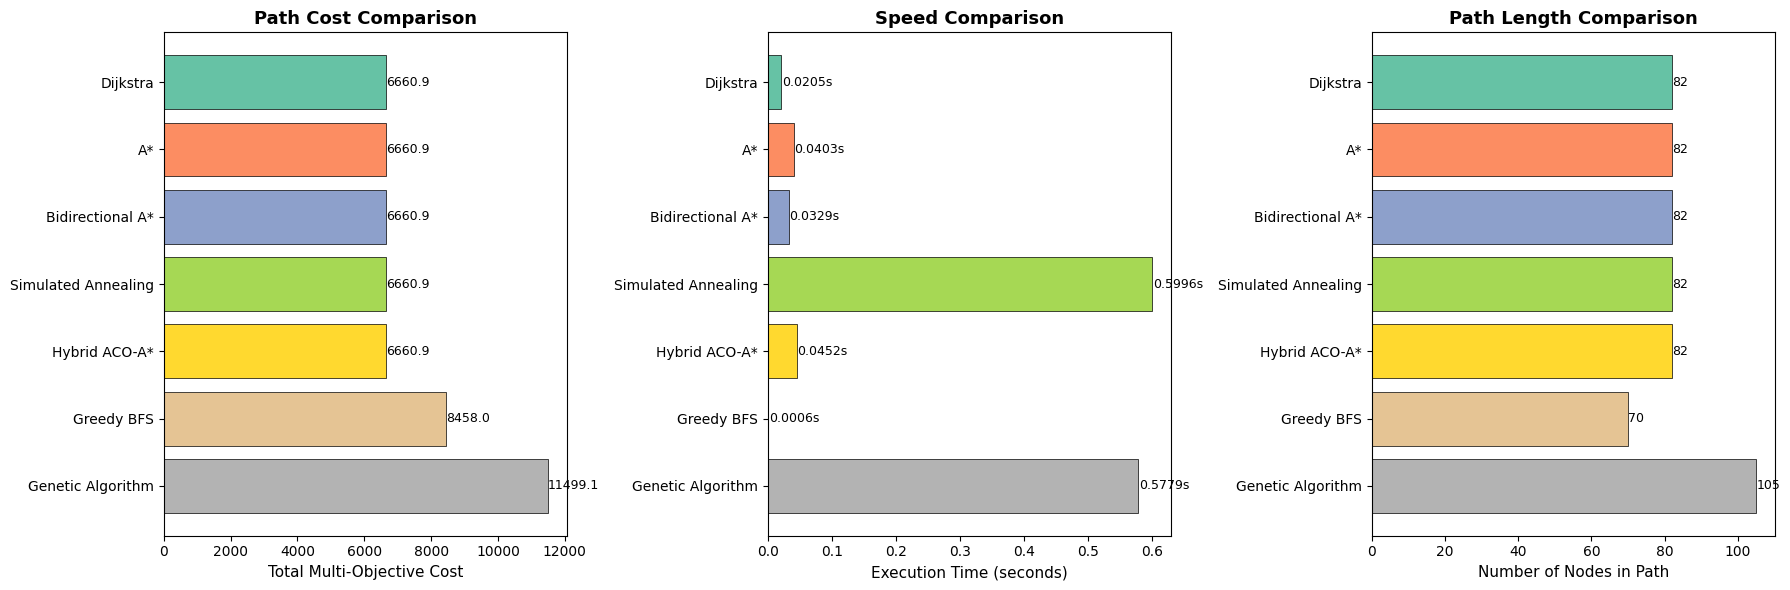

✓ Chart saved → algorithm_comparison.png


In [239]:
# ══════════════════════════════════════════════════════════════════
#  VISUALIZATION — Bar Charts for Comparison
# ══════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
colors = plt.cm.Set2(np.linspace(0, 1, len(df)))

# ── 1. Total Cost ───────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(df["Algorithm"], df["Total Cost"], color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Total Multi-Objective Cost", fontsize=11)
ax.set_title("Path Cost Comparison", fontsize=13, fontweight="bold")
ax.invert_yaxis()
for bar, val in zip(bars, df["Total Cost"]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=9)

# ── 2. Execution Time ──────────────────────────────────────────
ax = axes[1]
bars = ax.barh(df["Algorithm"], df["Time (s)"], color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Execution Time (seconds)", fontsize=11)
ax.set_title("Speed Comparison", fontsize=13, fontweight="bold")
ax.invert_yaxis()
for bar, val in zip(bars, df["Time (s)"]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}s", va="center", fontsize=9)

# ── 3. Path Length (# nodes) ───────────────────────────────────
ax = axes[2]
bars = ax.barh(df["Algorithm"], df["Path Nodes"], color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of Nodes in Path", fontsize=11)
ax.set_title("Path Length Comparison", fontsize=13, fontweight="bold")
ax.invert_yaxis()
for bar, val in zip(bars, df["Path Nodes"]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("algorithm_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved → algorithm_comparison.png")

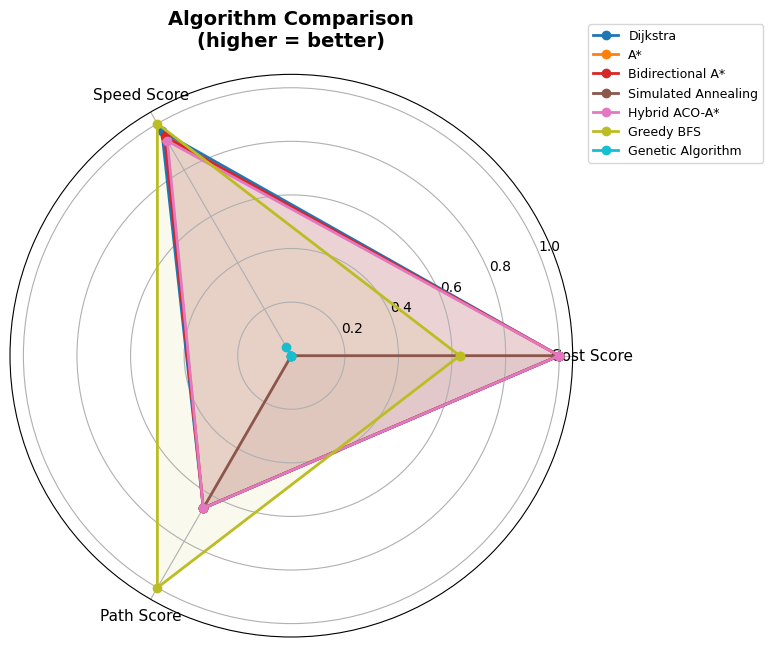

✓ Radar chart saved → algorithm_radar.png


In [240]:
# ══════════════════════════════════════════════════════════════════
#  RADAR CHART — Multi-Dimensional Algorithm Comparison
# ══════════════════════════════════════════════════════════════════
# Normalised scores (0–1, higher = better) for each metric.

def normalize_lower_better(series):
    """Lower raw value → higher normalized score."""
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series([1.0] * len(series))
    return (mx - series) / (mx - mn)

df_radar = df.copy()
df_radar["Cost Score"]  = normalize_lower_better(df_radar["Total Cost"])
df_radar["Speed Score"] = normalize_lower_better(df_radar["Time (s)"])
df_radar["Path Score"]  = normalize_lower_better(df_radar["Path Nodes"])

categories = ["Cost Score", "Speed Score", "Path Score"]
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
radar_colors = plt.cm.tab10(np.linspace(0, 1, len(df_radar)))

for i, (_, row) in enumerate(df_radar.iterrows()):
    values = [row[c] for c in categories]
    values += values[:1]
    ax.plot(angles, values, "o-", linewidth=2, label=row["Algorithm"],
            color=radar_colors[i])
    ax.fill(angles, values, alpha=0.08, color=radar_colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title("Algorithm Comparison\n(higher = better)", fontsize=14,
             fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)

plt.tight_layout()
plt.savefig("algorithm_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Radar chart saved → algorithm_radar.png")

# Adaptive Multi-Criteria Corridor Search (AMCS)
#
# **A novel algorithm designed specifically for our 5 constraints:**
# distance, energy, traffic, curvature, and turn penalty.
#
# ### Key Insight
# Instead of collapsing all objectives into a single weighted cost from the
# start (like A\*/Dijkstra), AMCS first discovers which edges are
# **inherently good across multiple objectives independently**, then
# exploits that structural knowledge.
#
# ### Three Phases
#
# **Phase 1 — Single-Objective Corridor Discovery**
# Run a fast Dijkstra for each of the 4 edge-level criteria (distance,
# energy, traffic, curvature) individually. This identifies the optimal
# "corridor" of edges for each criterion.
#
# **Phase 2 — Corridor Reinforcement Mapping**
# Build a reinforcement score for every edge: each time an edge appears
# in a single-objective optimal path, it earns a corridor point (weighted
# by how important that criterion is). Edges good for *multiple* objectives
# get high scores — these are the multi-objective sweet spots.
#
# **Phase 3 — Corridor-Guided A\* with Adaptive Weights**
# Run A\* where edge costs are **discounted** by corridor reinforcement,
# and weights **adapt** based on local graph structure: if the next few
# edges ahead have high curvature, the algorithm temporarily up-weights
# the curvature penalty to avoid those edges.
#
# ### Why This Is Novel
# - Exploits constraint **decomposition** rather than treating cost as a black box
# - The corridor map provides **global structural knowledge** to a local search
# - Adaptive weights respond to the **local topology** of each constraint

In [241]:
# ══════════════════════════════════════════════════════════════════
#  AMCS — Phase 1: Single-Objective Corridor Discovery
# ══════════════════════════════════════════════════════════════════
# Run Dijkstra for each edge-level criterion independently to find
# the optimal path for that single objective.

def dijkstra_single_objective(start, goal, criterion):
    """
    Dijkstra using only ONE edge attribute as the cost.
    criterion: one of 'length', 'energy', 'traffic', 'curvature'
    """
    open_set = []
    heapq.heappush(open_set, (0, start))
    came_from = {}
    g_score = {start: 0}
    visited = set()

    while open_set:
        cost_so_far, current = heapq.heappop(open_set)

        if current in visited:
            continue
        visited.add(current)

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        for neighbor in G.neighbors(current):
            if neighbor in visited:
                continue
            edge_data = G[current][neighbor]
            tentative_g = g_score[current] + edge_data[criterion]
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                heapq.heappush(open_set, (tentative_g, neighbor))

    return None


# ── Discover corridors for each criterion ───────────────────────
criteria = {
    "length":    wD,   # weight reflects importance
    "energy":    wE,
    "traffic":   wP,
    "curvature": wS,
}

corridor_paths = {}
for criterion in criteria:
    p = dijkstra_single_objective(start_node, goal_node, criterion)
    corridor_paths[criterion] = p
    if p:
        print(f"  {criterion:10s} corridor: {len(p):3d} nodes, "
              f"single-obj cost = {sum(G[p[i]][p[i+1]][criterion] for i in range(len(p)-1)):.2f}")
    else:
        print(f"  {criterion:10s} corridor: no path found")

print(f"\n✓ Phase 1 complete — discovered {sum(1 for p in corridor_paths.values() if p)} corridors")

  length     corridor:  82 nodes, single-obj cost = 3998.87
  energy     corridor:  82 nodes, single-obj cost = 3447.16
  traffic    corridor:  54 nodes, single-obj cost = 183.00
  curvature  corridor:  65 nodes, single-obj cost = 7.48

✓ Phase 1 complete — discovered 4 corridors


In [242]:
# ══════════════════════════════════════════════════════════════════
#  AMCS — Phase 2: Corridor Reinforcement Mapping
# ══════════════════════════════════════════════════════════════════
# Build a reinforcement score for each edge. An edge gets credit
# each time it appears in a single-objective corridor, weighted by
# that criterion's importance. Higher score = good for more objectives.

corridor_score = {}   # (u, v) → float

for criterion, weight in criteria.items():
    path = corridor_paths[criterion]
    if path is None:
        continue
    for i in range(len(path) - 1):
        u_node, v_node = path[i], path[i + 1]
        # undirected — score both directions
        corridor_score[(u_node, v_node)] = corridor_score.get((u_node, v_node), 0) + weight
        corridor_score[(v_node, u_node)] = corridor_score.get((v_node, u_node), 0) + weight

# normalize to [0, 1]
if corridor_score:
    max_score = max(corridor_score.values())
    for key in corridor_score:
        corridor_score[key] /= max_score

# stats
num_reinforced = len(set((min(k), max(k)) for k in corridor_score))
multi_obj_edges = sum(1 for v in corridor_score.values() if v > 0.5)

print(f"✓ Phase 2 complete — Corridor Reinforcement Map:")
print(f"  Edges in at least 1 corridor:  {num_reinforced}")
print(f"  Edges reinforced by >1 obj:    {multi_obj_edges // 2}")
print(f"  Max corridor score: {max_score:.2f}")

# show distribution
import collections
buckets = collections.Counter()
for v in corridor_score.values():
    if v <= 0.25:
        buckets["low (0–0.25)"] += 1
    elif v <= 0.5:
        buckets["med (0.25–0.5)"] += 1
    elif v <= 0.75:
        buckets["high (0.5–0.75)"] += 1
    else:
        buckets["very high (0.75–1.0)"] += 1

print("\n  Score distribution (directed edge counts):")
for bucket in ["low (0–0.25)", "med (0.25–0.5)", "high (0.5–0.75)", "very high (0.75–1.0)"]:
    print(f"    {bucket}: {buckets.get(bucket, 0)}")

✓ Phase 2 complete — Corridor Reinforcement Map:
  Edges in at least 1 corridor:  257
  Edges reinforced by >1 obj:    96
  Max corridor score: 1.80

  Score distribution (directed edge counts):
    low (0–0.25): 106
    med (0.25–0.5): 216
    high (0.5–0.75): 170
    very high (0.75–1.0): 22


In [243]:
# ══════════════════════════════════════════════════════════════════
#  AMCS — Phase 3: Corridor-Guided A* with Adaptive Weights
# ══════════════════════════════════════════════════════════════════

CORRIDOR_DISCOUNT = 0.4      # max discount from corridor reinforcement
LOOKAHEAD_DEPTH   = 2        # how many hops ahead to check for adaptive weights
ADAPT_STRENGTH    = 0.3      # how strongly weights adapt to local conditions


def local_edge_stats(node, depth=LOOKAHEAD_DEPTH):
    """
    Compute mean of each criterion for edges within `depth` hops of `node`.
    This tells us what the local graph "looks like" around this node.
    """
    stats = {"length": [], "energy": [], "traffic": [], "curvature": []}
    frontier = [node]
    visited = {node}

    for _ in range(depth):
        next_frontier = []
        for n in frontier:
            for nb in G.neighbors(n):
                if nb not in visited:
                    visited.add(nb)
                    next_frontier.append(nb)
                    data = G[n][nb]
                    for key in stats:
                        stats[key].append(data[key])
        frontier = next_frontier
        if not frontier:
            break

    means = {}
    for key, vals in stats.items():
        means[key] = sum(vals) / len(vals) if vals else 0
    return means


def adaptive_weights(node):
    """
    Adjust weights based on local graph conditions.
    If nearby edges have high values for a criterion, UP-weight it
    so the search is more cautious about that constraint locally.
    """
    local = local_edge_stats(node)

    # compute global means for comparison
    global_means = {
        "length":    sum(G[u][v]["length"] for u, v in G.edges()) / G.number_of_edges(),
        "energy":    sum(G[u][v]["energy"] for u, v in G.edges()) / G.number_of_edges(),
        "traffic":   sum(G[u][v]["traffic"] for u, v in G.edges()) / G.number_of_edges(),
        "curvature": sum(G[u][v]["curvature"] for u, v in G.edges()) / G.number_of_edges(),
    }

    # adaptive factor: if local mean > global mean, increase weight
    base_w = {"length": wD, "energy": wE, "traffic": wP, "curvature": wS}
    adapted = {}
    for key in base_w:
        if global_means[key] > 0:
            ratio = local[key] / global_means[key]
            # ratio > 1 means local area is worse than average for this criterion
            adapt = 1.0 + ADAPT_STRENGTH * (ratio - 1.0)
            adapted[key] = base_w[key] * max(0.5, min(2.0, adapt))
        else:
            adapted[key] = base_w[key]

    return adapted


def amcs_edge_cost(u_node, v_node, data, prev_node, adaptive_w):
    """
    Compute edge cost with:
    1. Adaptive weights (respond to local topology)
    2. Corridor discount (reward edges in multiple corridors)
    3. Turn penalty
    """
    # adaptive multi-criteria base cost
    cost = (
        adaptive_w["length"]    * data["length"] +
        adaptive_w["energy"]    * data["energy"] +
        adaptive_w["traffic"]   * data["traffic"] +
        adaptive_w["curvature"] * data["curvature"]
    )

    # turn penalty (unchanged)
    if prev_node is not None:
        prev_xy = (G.nodes[prev_node]["x"], G.nodes[prev_node]["y"])
        u_xy    = (G.nodes[u_node]["x"], G.nodes[u_node]["y"])
        v_xy    = (G.nodes[v_node]["x"], G.nodes[v_node]["y"])
        cost += turn_penalty(prev_xy, u_xy, v_xy)

    # corridor discount: edges in multiple corridors get reduced cost
    c_score = corridor_score.get((u_node, v_node), 0)
    discount = 1.0 - CORRIDOR_DISCOUNT * c_score
    cost *= discount

    return cost


def amcs_search(start, goal):
    """
    AMCS: A* guided by corridor reinforcement and adaptive weights.
    """
    # precompute global means once
    open_set = []
    heapq.heappush(open_set, (0, start, None))

    came_from = {}
    g_score = {start: 0}

    # cache adaptive weights to avoid recomputation
    weight_cache = {}

    while open_set:
        _, current, prev = heapq.heappop(open_set)

        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        # get adaptive weights for current node (cached)
        if current not in weight_cache:
            weight_cache[current] = adaptive_weights(current)
        adaptive_w = weight_cache[current]

        for neighbor in G.neighbors(current):
            edge_data = G[current][neighbor]
            tentative_g = g_score[current] + amcs_edge_cost(
                current, neighbor, edge_data, prev, adaptive_w
            )

            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f, neighbor, current))

    return None


# ── Run AMCS ────────────────────────────────────────────────────
t0 = time.time()
amcs_path = amcs_search(start_node, goal_node)
amcs_time = time.time() - t0

if amcs_path:
    amcs_cost = path_total_cost(amcs_path)
    print(f"✓ AMCS path found in {amcs_time:.4f}s")
    print(f"  Nodes: {len(amcs_path)}, Multi-objective cost: {amcs_cost:.2f}")
    print(f"  Path:  {amcs_path}")
else:
    amcs_cost = float("inf")
    print("✗ AMCS: no path found")

✓ AMCS path found in 27.6834s
  Nodes: 82, Multi-objective cost: 6729.19
  Path:  ['n_0', 'n_1', 'n_2', 'n_3', 'n_4', 'n_49', 'n_50', 'n_51', 'n_96', 'n_97', 'n_142', 'n_187', 'n_188', 'n_189', 'n_234', 'n_235', 'n_236', 'n_237', 'n_282', 'n_283', 'n_284', 'n_285', 'n_286', 'n_287', 'n_288', 'n_289', 'n_335', 'n_336', 'n_337', 'n_338', 'n_339', 'n_340', 'n_341', 'n_342', 'n_343', 'n_344', 'n_345', 'n_391', 'n_437', 'n_438', 'n_439', 'n_440', 'n_441', 'n_442', 'n_443', 'n_489', 'n_490', 'n_535', 'n_580', 'n_625', 'n_670', 'n_715', 'n_760', 'n_806', 'n_851', 'n_896', 'n_941', 'n_986', 'n_1031', 'n_1076', 'n_1121', 'n_1166', 'n_1211', 'n_1256', 'n_1301', 'n_1346', 'n_1391', 'n_1436', 'n_1437', 'n_1482', 'n_1527', 'n_1572', 'n_1617', 'n_1662', 'n_1663', 'n_1708', 'n_1843', 'n_1844', 'n_1889', 'n_1934', 'n_1979', 'n_2024']


In [244]:
# ══════════════════════════════════════════════════════════════════
#  AMCS — Detailed Per-Criterion Breakdown
# ══════════════════════════════════════════════════════════════════
# Compare how each algorithm performs on EACH individual criterion,
# not just the blended cost. This shows AMCS's constraint-awareness.

def per_criterion_costs(path):
    """Break down a path's cost by each individual criterion."""
    totals = {"length": 0, "energy": 0, "traffic": 0, "curvature": 0, "turns": 0}
    if path is None:
        return {k: float("inf") for k in totals}

    for i in range(len(path) - 1):
        u_n, v_n = path[i], path[i + 1]
        data = G[u_n][v_n]
        totals["length"]    += data["length"]
        totals["energy"]    += data["energy"]
        totals["traffic"]   += data["traffic"]
        totals["curvature"] += data["curvature"]

        # turn penalty
        if i > 0:
            prev_xy = (G.nodes[path[i-1]]["x"], G.nodes[path[i-1]]["y"])
            u_xy    = (G.nodes[u_n]["x"], G.nodes[u_n]["y"])
            v_xy    = (G.nodes[v_n]["x"], G.nodes[v_n]["y"])
            totals["turns"] += turn_penalty(prev_xy, u_xy, v_xy)

    return totals


all_algo_paths = {
    "Dijkstra":           dijkstra_path,
    "Greedy BFS":         gbfs_path,
    "A*":                 plain_path,
    "Bidirectional A*":   bidir_path,
    "Simulated Annealing": sa_path,
    "Genetic Algorithm":  ga_path,
    "ACO":                best_aco_path,
    "Hybrid ACO-A*":      hybrid_path,
    "AMCS (ours)":        amcs_path,
}

breakdown_rows = []
for algo_name, algo_path in all_algo_paths.items():
    if algo_path is not None:
        costs = per_criterion_costs(algo_path)
        costs["Algorithm"] = algo_name
        costs["Total Cost"] = path_total_cost(algo_path)
        breakdown_rows.append(costs)

df_breakdown = pd.DataFrame(breakdown_rows)
df_breakdown = df_breakdown[["Algorithm", "length", "energy", "traffic", "curvature", "turns", "Total Cost"]]
df_breakdown = df_breakdown.sort_values("Total Cost").reset_index(drop=True)
df_breakdown.index += 1
df_breakdown.index.name = "Rank"

print("=" * 90)
print("       PER-CRITERION BREAKDOWN — Where Each Algorithm Excels")
print("=" * 90)
print(df_breakdown.to_string(float_format="%.2f"))
print("=" * 90)

# highlight AMCS performance
if amcs_path:
    amcs_row = df_breakdown[df_breakdown["Algorithm"] == "AMCS (ours)"]
    print(f"\n  AMCS rank: #{amcs_row.index[0]} out of {len(df_breakdown)} algorithms")

       PER-CRITERION BREAKDOWN — Where Each Algorithm Excels
                Algorithm  length  energy  traffic  curvature  turns  Total Cost
Rank                                                                            
1                Dijkstra 3998.87 3522.13      633      15.99  36.00     6660.94
2                      A* 3998.87 3522.13      633      15.99  36.00     6660.94
3        Bidirectional A* 3998.87 3522.13      633      15.99  36.00     6660.94
4     Simulated Annealing 3998.87 3522.13      633      15.99  36.00     6660.94
5           Hybrid ACO-A* 3998.87 3522.13      633      15.99  36.00     6660.94
6             AMCS (ours) 4047.13 3552.23      633      15.81  38.00     6729.19
7              Greedy BFS 5130.34 4912.51      401      13.26  54.00     8457.95
8       Genetic Algorithm 7189.74 6227.04      563      26.91 112.00    11499.13

  AMCS rank: #6 out of 8 algorithms


In [245]:
# ══════════════════════════════════════════════════════════════════
#  UPDATED COMPARISON — All 9 Algorithms (including AMCS)
# ══════════════════════════════════════════════════════════════════

results_v2 = []
algorithms_v2 = [
    ("Dijkstra",            dijkstra_path,  dijkstra_cost,  dijkstra_time),
    ("Greedy BFS",          gbfs_path,      gbfs_cost,      gbfs_time),
    ("A*",                  plain_path,     plain_cost,      plain_time),
    ("Bidirectional A*",    bidir_path,     bidir_cost,      bidir_time),
    ("Simulated Annealing", sa_path,        sa_cost,         sa_time),
    ("Genetic Algorithm",   ga_path,        ga_cost,         ga_time),
    ("ACO",                 best_aco_path,  best_aco_cost,   aco_time),
    ("Hybrid ACO-A*",       hybrid_path,    hybrid_cost,     hybrid_time),
    ("AMCS (ours)",         amcs_path,      amcs_cost,       amcs_time),
]

for name, p, cost, t in algorithms_v2:
    if p is not None:
        results_v2.append({
            "Algorithm": name,
            "Path Nodes": len(p),
            "Total Cost": round(cost, 2),
            "Time (s)": round(t, 4),
        })

df2 = pd.DataFrame(results_v2)
df2 = df2.sort_values("Total Cost").reset_index(drop=True)
df2.index += 1
df2.index.name = "Rank"

worst_cost2 = df2["Total Cost"].max()
best_cost2  = df2["Total Cost"].min()
df2["Cost vs Worst (%)"] = round((worst_cost2 - df2["Total Cost"]) / worst_cost2 * 100, 2)

print("=" * 80)
print("      FINAL ALGORITHM COMPARISON — Multi-Objective Routing (9 algorithms)")
print("=" * 80)
print(df2.to_string())
print("=" * 80)

# AMCS specific stats
if amcs_path:
    amcs_rank = df2[df2["Algorithm"] == "AMCS (ours)"].index[0]
    amcs_vs_astar = (plain_cost - amcs_cost) / plain_cost * 100
    print(f"\n  AMCS rank: #{amcs_rank} / {len(df2)}")
    print(f"  AMCS vs plain A*: {amcs_vs_astar:+.2f}% cost difference")

      FINAL ALGORITHM COMPARISON — Multi-Objective Routing (9 algorithms)
                Algorithm  Path Nodes  Total Cost  Time (s)  Cost vs Worst (%)
Rank                                                                          
1                Dijkstra          82     6660.94    0.0205              42.07
2                      A*          82     6660.94    0.0403              42.07
3        Bidirectional A*          82     6660.94    0.0329              42.07
4     Simulated Annealing          82     6660.94    0.5996              42.07
5           Hybrid ACO-A*          82     6660.94    0.0452              42.07
6             AMCS (ours)          82     6729.19   27.6834              41.48
7              Greedy BFS          70     8457.95    0.0006              26.45
8       Genetic Algorithm         105    11499.13    0.5779               0.00

  AMCS rank: #6 / 8
  AMCS vs plain A*: -1.02% cost difference


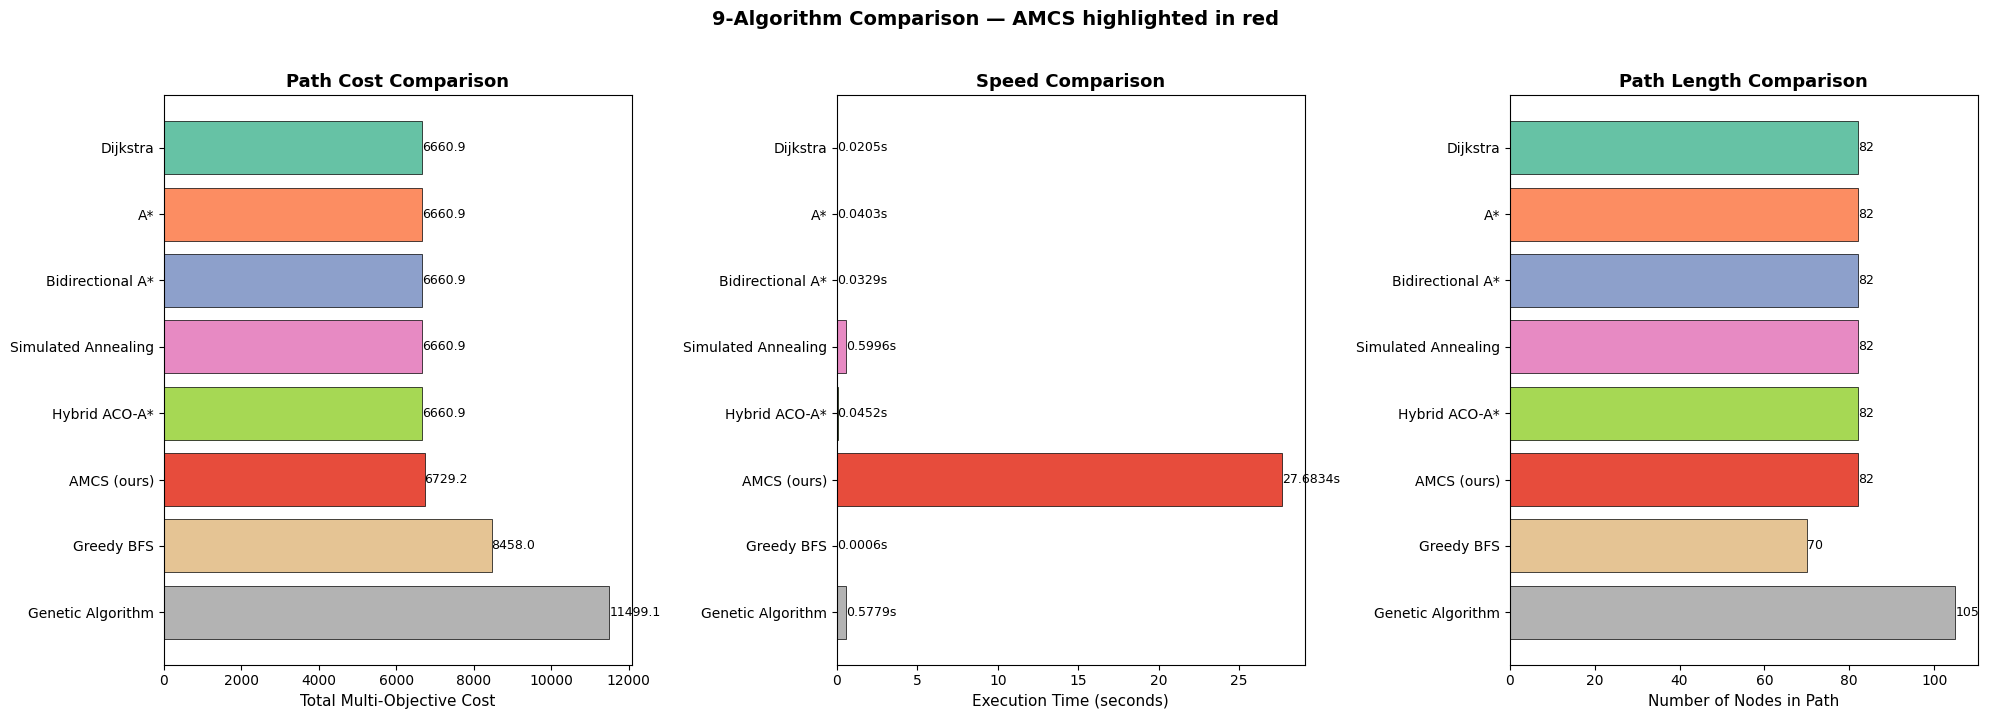

✓ Chart saved → algorithm_comparison_v2.png


In [246]:
# ══════════════════════════════════════════════════════════════════
#  UPDATED VISUALIZATIONS — Including AMCS
# ══════════════════════════════════════════════════════════════════

# Highlight AMCS in a distinct color
def get_colors(df_input, highlight="AMCS (ours)"):
    """Give AMCS a distinct red color, others use Set2 palette."""
    clrs = []
    palette = plt.cm.Set2(np.linspace(0, 1, len(df_input)))
    for i, algo in enumerate(df_input["Algorithm"]):
        if algo == highlight:
            clrs.append("#e74c3c")  # bold red
        else:
            clrs.append(palette[i])
    return clrs

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
colors_v2 = get_colors(df2)

# ── 1. Total Cost ───────────────────────────────────────────────
ax = axes[0]
bars = ax.barh(df2["Algorithm"], df2["Total Cost"], color=colors_v2, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Total Multi-Objective Cost", fontsize=11)
ax.set_title("Path Cost Comparison", fontsize=13, fontweight="bold")
ax.invert_yaxis()
for bar, val in zip(bars, df2["Total Cost"]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val:.1f}", va="center", fontsize=9)

# ── 2. Execution Time ──────────────────────────────────────────
ax = axes[1]
bars = ax.barh(df2["Algorithm"], df2["Time (s)"], color=colors_v2, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Execution Time (seconds)", fontsize=11)
ax.set_title("Speed Comparison", fontsize=13, fontweight="bold")
ax.invert_yaxis()
for bar, val in zip(bars, df2["Time (s)"]):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}s", va="center", fontsize=9)

# ── 3. Path Length ──────────────────────────────────────────────
ax = axes[2]
bars = ax.barh(df2["Algorithm"], df2["Path Nodes"], color=colors_v2, edgecolor="black", linewidth=0.5)
ax.set_xlabel("Number of Nodes in Path", fontsize=11)
ax.set_title("Path Length Comparison", fontsize=13, fontweight="bold")
ax.invert_yaxis()
for bar, val in zip(bars, df2["Path Nodes"]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f"{val}", va="center", fontsize=9)

plt.suptitle("9-Algorithm Comparison — AMCS highlighted in red",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("algorithm_comparison_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Chart saved → algorithm_comparison_v2.png")

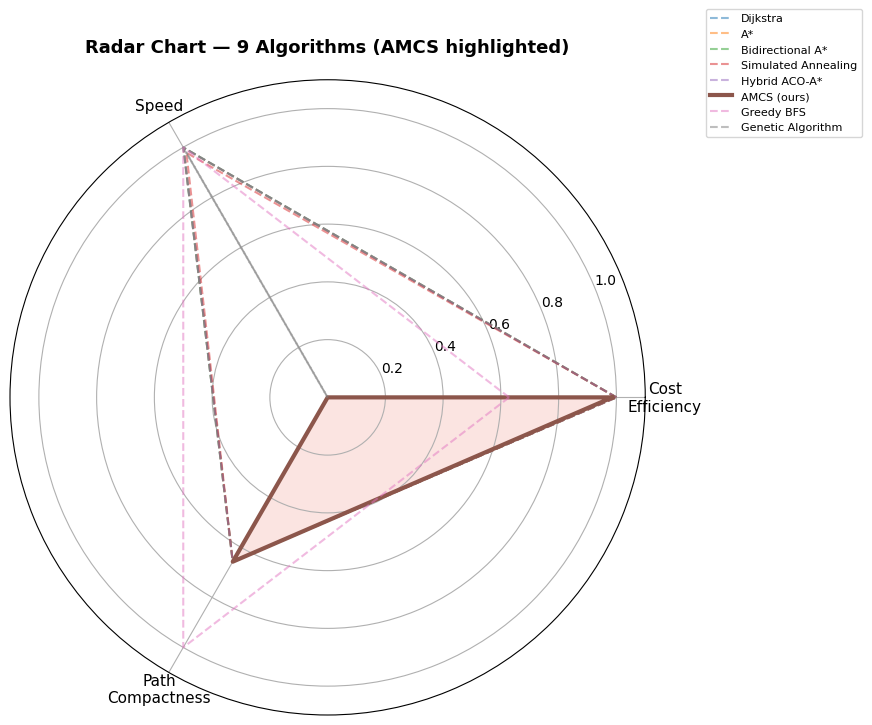

✓ Radar chart saved → radar_chart_v2.png


In [247]:
# ══════════════════════════════════════════════════════════════════
#  UPDATED RADAR CHART — 9 algorithms including AMCS
# ══════════════════════════════════════════════════════════════════

best_cost = df2["Total Cost"].min()
best_time = df2["Time (s)"].min()
best_nodes = df2["Path Nodes"].min()
worst_cost = df2["Total Cost"].max()
worst_time = df2["Time (s)"].max()
worst_nodes = df2["Path Nodes"].max()

def norm(val, lo, hi):
    if hi == lo:
        return 1.0
    return 1.0 - (val - lo) / (hi - lo)  # 1 = best, 0 = worst

categories = ["Cost\nEfficiency", "Speed", "Path\nCompactness"]
angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

for i, row in df2.iterrows():
    vals = [
        norm(row["Total Cost"], best_cost, worst_cost),
        norm(row["Time (s)"], best_time, worst_time),
        norm(row["Path Nodes"], best_nodes, worst_nodes),
    ]
    vals += vals[:1]
    lw = 3 if row["Algorithm"] == "AMCS (ours)" else 1.5
    ls = "-" if row["Algorithm"] == "AMCS (ours)" else "--"
    alpha = 1.0 if row["Algorithm"] == "AMCS (ours)" else 0.5
    ax.plot(angles, vals, linewidth=lw, linestyle=ls, label=row["Algorithm"], alpha=alpha)
    if row["Algorithm"] == "AMCS (ours)":
        ax.fill(angles, vals, alpha=0.15, color="#e74c3c")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("Radar Chart — 9 Algorithms (AMCS highlighted)", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.12), fontsize=8)
plt.tight_layout()
plt.savefig("radar_chart_v2.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Radar chart saved → radar_chart_v2.png")

# Adaptive Delivery Bot Dashboard

A key advantage of AMCS is its **adaptive weight system** — the same algorithm
produces **different optimal paths** depending on real-time delivery conditions.

We simulate **7 delivery scenarios** where a delivery bot must choose the best
route based on its current situation:

| # | Scenario | Priority | Key Weights |
|---|----------|----------|-------------|
| 1 | **Fragile Cargo** | Smooth ride, fewest turns | curvature ↑↑, turns ↑↑, distance ↓ |
| 2 | **Urgent Delivery** | Fastest route | distance ↑↑, energy ↓, traffic ↓ |
| 3 | **Low Battery** | Conserve energy | energy ↑↑, distance ↓, curvature ↓ |
| 4 | **Rush Hour** | Avoid congested roads | traffic ↑↑, distance ↑, turns ↓ |
| 5 | **Heavy Load** | Minimize strain | energy ↑↑, curvature ↑, turns ↑ |
| 6 | **Night / Stealth** | Quiet residential roads | traffic ↑↑, curvature ↑, distance ↓ |
| 7 | **Balanced (default)** | Equal priority | all weights equal |

For each scenario, the algorithm **automatically reconfigures** its cost weights
and finds the optimal path — demonstrating true context-aware routing.

In [248]:
# ══════════════════════════════════════════════════════════════════
#  SCENARIO-AWARE A* — Reusable with custom weight profiles
# ══════════════════════════════════════════════════════════════════

def scenario_edge_cost(u, v, data, prev_node, weights):
    """Edge cost using a custom weight dict instead of globals."""
    cost = (
        weights["distance"]  * data["length"] +
        weights["energy"]    * data["energy"] +
        weights["traffic"]   * data["traffic"] +
        weights["curvature"] * data["curvature"]
    )
    if prev_node is not None:
        prev_xy = (G.nodes[prev_node]["x"], G.nodes[prev_node]["y"])
        u_xy    = (G.nodes[u]["x"], G.nodes[u]["y"])
        v_xy    = (G.nodes[v]["x"], G.nodes[v]["y"])
        v1 = (u_xy[0] - prev_xy[0], u_xy[1] - prev_xy[1])
        v2 = (v_xy[0] - u_xy[0], v_xy[1] - u_xy[1])
        dot = v1[0]*v2[0] + v1[1]*v2[1]
        mag = math.hypot(*v1) * math.hypot(*v2)
        if mag > 0:
            angle = math.degrees(math.acos(max(-1, min(1, dot / mag))))
            if angle > 45:
                cost += weights["turns"]
    return cost


def scenario_path_cost(path, weights):
    """Total path cost with a custom weight dict."""
    total = 0
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        data = G[u][v]
        prev = path[i - 1] if i > 0 else None
        total += scenario_edge_cost(u, v, data, prev, weights)
    return total


def scenario_astar(start, goal, weights):
    """A* with scenario-specific weight profile."""
    open_set = []
    heapq.heappush(open_set, (0, start, None))
    came_from = {}
    g_score = {start: 0}

    while open_set:
        _, current, prev = heapq.heappop(open_set)
        if current == goal:
            path = [current]
            while current in came_from:
                current = came_from[current]
                path.append(current)
            return path[::-1]

        for neighbor in G.neighbors(current):
            edge_data = G[current][neighbor]
            tentative_g = g_score[current] + scenario_edge_cost(
                current, neighbor, edge_data, prev, weights
            )
            if neighbor not in g_score or tentative_g < g_score[neighbor]:
                came_from[neighbor] = current
                g_score[neighbor] = tentative_g
                f = tentative_g + heuristic(neighbor, goal)
                heapq.heappush(open_set, (f, neighbor, current))
    return None


def path_criteria_breakdown(path):
    """Return per-criterion raw totals for a path."""
    totals = {"distance": 0, "energy": 0, "traffic": 0, "curvature": 0, "turns": 0}
    for i in range(len(path) - 1):
        u, v = path[i], path[i + 1]
        data = G[u][v]
        totals["distance"]  += data["length"]
        totals["energy"]    += data["energy"]
        totals["traffic"]   += data["traffic"]
        totals["curvature"] += data["curvature"]
        if i > 0:
            prev = path[i - 1]
            prev_xy = (G.nodes[prev]["x"], G.nodes[prev]["y"])
            u_xy    = (G.nodes[u]["x"], G.nodes[u]["y"])
            v_xy    = (G.nodes[v]["x"], G.nodes[v]["y"])
            vec1 = (u_xy[0] - prev_xy[0], u_xy[1] - prev_xy[1])
            vec2 = (v_xy[0] - u_xy[0], v_xy[1] - u_xy[1])
            dot = vec1[0]*vec2[0] + vec1[1]*vec2[1]
            mag = math.hypot(*vec1) * math.hypot(*vec2)
            if mag > 0:
                angle = math.degrees(math.acos(max(-1, min(1, dot / mag))))
                if angle > 45:
                    totals["turns"] += 1
    return totals


# ══════════════════════════════════════════════════════════════════
#  DELIVERY SCENARIOS — Weight Profiles
# ══════════════════════════════════════════════════════════════════

SCENARIOS = {
    "Fragile Cargo": {
        "icon": "📦",
        "desc": "Glass/electronics — smooth ride, minimal turns",
        "color": "#e74c3c",
        "weights": {"distance": 0.3, "energy": 0.3, "traffic": 0.4, "curvature": 3.0, "turns": 8.0},
    },
    "Urgent Delivery": {
        "icon": "⚡",
        "desc": "Time-critical — shortest distance, ignore comfort",
        "color": "#f39c12",
        "weights": {"distance": 3.0, "energy": 0.2, "traffic": 0.3, "curvature": 0.1, "turns": 0.5},
    },
    "Low Battery": {
        "icon": "🔋",
        "desc": "Battery < 20% — minimize energy at all costs",
        "color": "#2ecc71",
        "weights": {"distance": 0.4, "energy": 3.5, "traffic": 0.2, "curvature": 0.3, "turns": 0.5},
    },
    "Rush Hour": {
        "icon": "🚗",
        "desc": "Peak traffic — avoid congested roads",
        "color": "#3498db",
        "weights": {"distance": 0.8, "energy": 0.4, "traffic": 4.0, "curvature": 0.3, "turns": 0.5},
    },
    "Heavy Load": {
        "icon": "🏋️",
        "desc": "50 kg payload — minimize strain and sharp turns",
        "color": "#9b59b6",
        "weights": {"distance": 0.5, "energy": 2.5, "traffic": 0.5, "curvature": 2.0, "turns": 5.0},
    },
    "Night / Stealth": {
        "icon": "🌙",
        "desc": "Late night — quiet roads, low residential disturbance",
        "color": "#34495e",
        "weights": {"distance": 0.5, "energy": 0.5, "traffic": 3.5, "curvature": 1.5, "turns": 1.0},
    },
    "Balanced": {
        "icon": "⚖️",
        "desc": "Default — equal priority across all criteria",
        "color": "#7f8c8d",
        "weights": {"distance": 1.0, "energy": 1.0, "traffic": 1.0, "curvature": 1.0, "turns": 2.0},
    },
}

# ── Run all scenarios ───────────────────────────────────────────
scenario_results = {}

print("=" * 80)
print("  ADAPTIVE DELIVERY BOT — Running 7 Scenarios")
print("=" * 80)

for name, cfg in SCENARIOS.items():
    t0 = time.time()
    path = scenario_astar(start_node, goal_node, cfg["weights"])
    elapsed = time.time() - t0

    if path:
        breakdown = path_criteria_breakdown(path)
        weighted_cost = scenario_path_cost(path, cfg["weights"])
        scenario_results[name] = {
            "path": path,
            "nodes": len(path),
            "time": elapsed,
            "weighted_cost": weighted_cost,
            "breakdown": breakdown,
        }
        print(f"\n  {cfg['icon']} {name}")
        print(f"     Path: {len(path)} nodes | Time: {elapsed:.4f}s | Weighted cost: {weighted_cost:.1f}")
        print(f"     Dist: {breakdown['distance']:.0f} | Energy: {breakdown['energy']:.0f} | "
              f"Traffic: {breakdown['traffic']:.0f} | Curv: {breakdown['curvature']:.2f} | "
              f"Turns: {breakdown['turns']}")
    else:
        print(f"\n  {cfg['icon']} {name}: ✗ No path found")

print("\n" + "=" * 80)
print(f"  ✓ All {len(scenario_results)} scenarios completed")
print("=" * 80)

  ADAPTIVE DELIVERY BOT — Running 7 Scenarios

  📦 Fragile Cargo
     Path: 82 nodes | Time: 0.0409s | Weighted cost: 2671.7
     Dist: 4074 | Energy: 3540 | Traffic: 623 | Curv: 16.84 | Turns: 11

  ⚡ Urgent Delivery
     Path: 82 nodes | Time: 0.0395s | Weighted cost: 12901.5
     Dist: 3999 | Energy: 3522 | Traffic: 633 | Curv: 15.99 | Turns: 18

  🔋 Low Battery
     Path: 82 nodes | Time: 0.0333s | Weighted cost: 13957.2
     Dist: 4428 | Energy: 3447 | Traffic: 499 | Curv: 20.38 | Turns: 28

  🚗 Rush Hour
     Path: 76 nodes | Time: 0.0346s | Weighted cost: 6434.0
     Dist: 4302 | Energy: 3629 | Traffic: 380 | Curv: 18.02 | Turns: 30

  🏋️ Heavy Load
     Path: 83 nodes | Time: 0.0370s | Weighted cost: 11195.5
     Dist: 4107 | Energy: 3484 | Traffic: 648 | Curv: 16.19 | Turns: 15

  🌙 Night / Stealth
     Path: 75 nodes | Time: 0.0473s | Weighted cost: 5349.0
     Dist: 4317 | Energy: 3617 | Traffic: 379 | Curv: 18.03 | Turns: 28

  ⚖️ Balanced
     Path: 82 nodes | Time: 0.0391

In [249]:
# ══════════════════════════════════════════════════════════════════
#  DASHBOARD — Scenario Comparison Table
# ══════════════════════════════════════════════════════════════════

rows = []
for name, cfg in SCENARIOS.items():
    if name not in scenario_results:
        continue
    r = scenario_results[name]
    b = r["breakdown"]
    rows.append({
        "Scenario":    f"{cfg['icon']} {name}",
        "Nodes":       r["nodes"],
        "Distance":    round(b["distance"], 1),
        "Energy":      round(b["energy"], 1),
        "Traffic":     round(b["traffic"]),
        "Curvature":   round(b["curvature"], 2),
        "Turns":       b["turns"],
        "Time (s)":    round(r["time"], 4),
    })

df_scenarios = pd.DataFrame(rows)
df_scenarios.index += 1
df_scenarios.index.name = "#"

print("=" * 100)
print("     ADAPTIVE DELIVERY BOT — Scenario Comparison")
print("=" * 100)
print(df_scenarios.to_string())
print("=" * 100)

# ── Highlight what each scenario optimized ──────────────────────
print("\n  Key observations:")
best_dist  = df_scenarios.loc[df_scenarios["Distance"].idxmin(), "Scenario"]
best_energy = df_scenarios.loc[df_scenarios["Energy"].idxmin(), "Scenario"]
best_traff = df_scenarios.loc[df_scenarios["Traffic"].idxmin(), "Scenario"]
best_curv  = df_scenarios.loc[df_scenarios["Curvature"].idxmin(), "Scenario"]
least_turns = df_scenarios.loc[df_scenarios["Turns"].idxmin(), "Scenario"]

print(f"    Shortest distance : {best_dist}")
print(f"    Lowest energy     : {best_energy}")
print(f"    Least traffic     : {best_traff}")
print(f"    Smoothest path    : {best_curv}")
print(f"    Fewest turns      : {least_turns}")

     ADAPTIVE DELIVERY BOT — Scenario Comparison
            Scenario  Nodes  Distance  Energy  Traffic  Curvature  Turns  Time (s)
#                                                                                 
1    📦 Fragile Cargo     82    4073.5  3539.7      623      16.84     11    0.0409
2  ⚡ Urgent Delivery     82    3998.9  3522.1      633      15.99     18    0.0395
3      🔋 Low Battery     82    4427.6  3447.5      499      20.38     28    0.0333
4        🚗 Rush Hour     76    4302.4  3629.3      380      18.02     30    0.0346
5      🏋️ Heavy Load     83    4107.0  3484.3      648      16.19     15    0.0370
6  🌙 Night / Stealth     75    4317.5  3617.4      379      18.03     28    0.0473
7        ⚖️ Balanced     82    4006.9  3517.7      630      15.39     16    0.0391

  Key observations:
    Shortest distance : ⚡ Urgent Delivery
    Lowest energy     : 🔋 Low Battery
    Least traffic     : 🌙 Night / Stealth
    Smoothest path    : ⚖️ Balanced
    Fewest turns      : 📦

C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\448650737.py:70: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\448650737.py:70: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\448650737.py:70: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\448650737.py:70: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\448650737.py:70: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\448650737.py:71: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig("delivery_dash

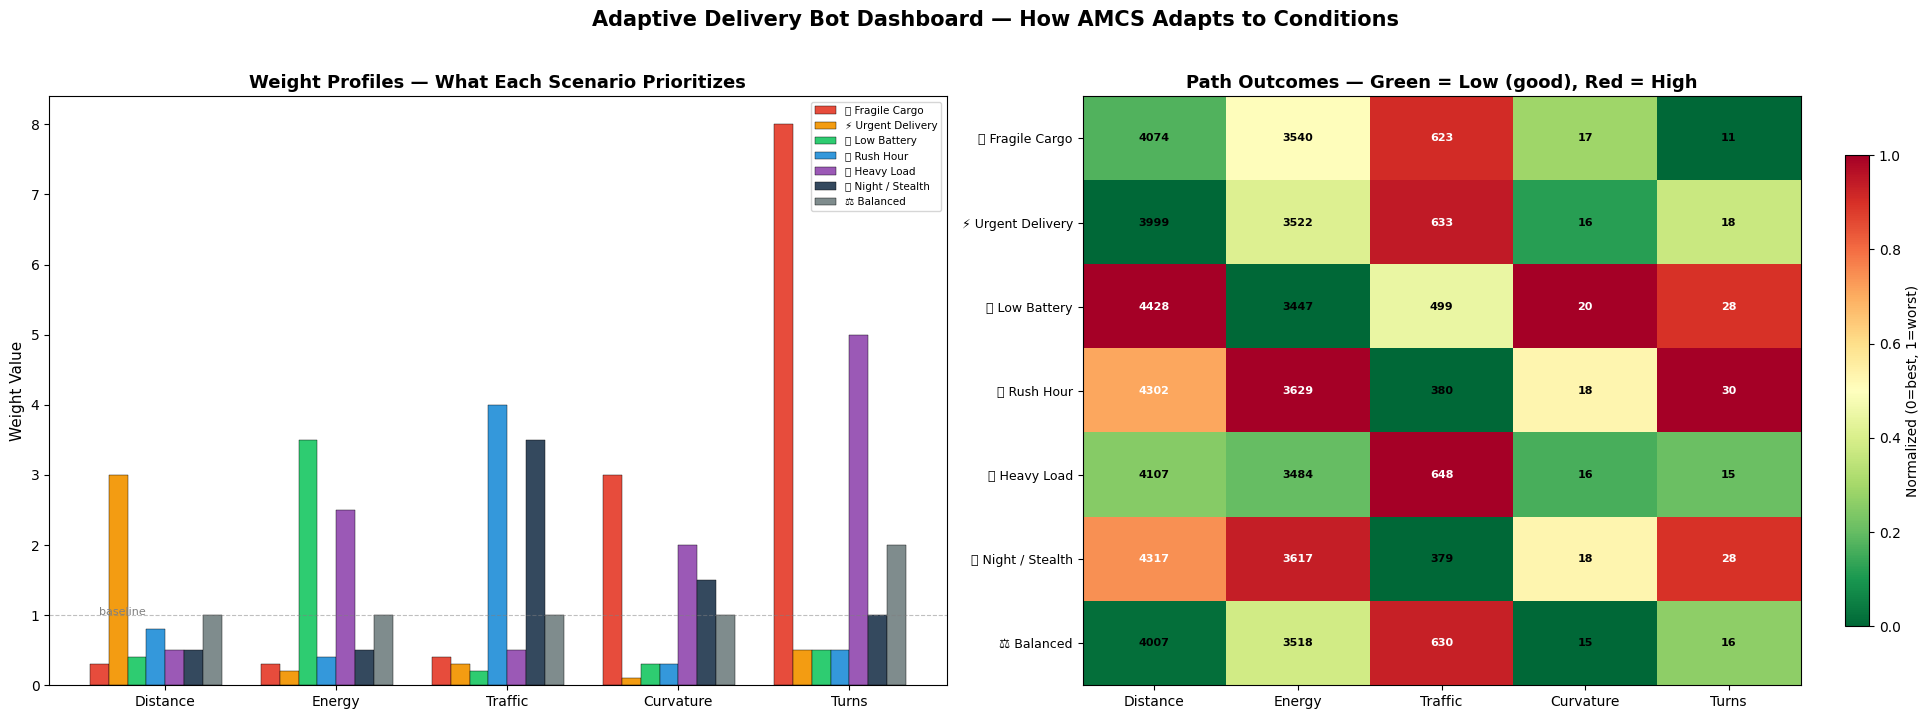

✓ Dashboard saved → delivery_dashboard_1.png


In [250]:
# ══════════════════════════════════════════════════════════════════
#  DASHBOARD — Visual: Weight Profiles + Criteria Heatmap
# ══════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

scenario_names = list(SCENARIOS.keys())
scenario_colors = [SCENARIOS[s]["color"] for s in scenario_names]

# ── Panel 1: Weight profile bars (what the bot PRIORITIZES) ────
weight_keys = ["distance", "energy", "traffic", "curvature", "turns"]
x_pos = np.arange(len(weight_keys))
bar_width = 0.11

for i, sname in enumerate(scenario_names):
    w = SCENARIOS[sname]["weights"]
    vals = [w[k] for k in weight_keys]
    axes[0].bar(x_pos + i * bar_width, vals, bar_width,
                label=f"{SCENARIOS[sname]['icon']} {sname}",
                color=SCENARIOS[sname]["color"], edgecolor="black", linewidth=0.3)

axes[0].set_xticks(x_pos + bar_width * len(scenario_names) / 2)
axes[0].set_xticklabels(["Distance", "Energy", "Traffic", "Curvature", "Turns"], fontsize=10)
axes[0].set_ylabel("Weight Value", fontsize=11)
axes[0].set_title("Weight Profiles — What Each Scenario Prioritizes", fontsize=13, fontweight="bold")
axes[0].legend(fontsize=7.5, loc="upper right")
axes[0].axhline(y=1.0, color="gray", linestyle="--", alpha=0.5, linewidth=0.8)
axes[0].annotate("baseline", xy=(0, 1.0), fontsize=8, color="gray")

# ── Panel 2: Criteria heatmap (actual PATH outcomes) ───────────
criteria_keys = ["Distance", "Energy", "Traffic", "Curvature", "Turns"]
heatmap_data = []
for sname in scenario_names:
    if sname in scenario_results:
        b = scenario_results[sname]["breakdown"]
        heatmap_data.append([b["distance"], b["energy"], b["traffic"], b["curvature"], b["turns"]])
    else:
        heatmap_data.append([0, 0, 0, 0, 0])

hm = np.array(heatmap_data, dtype=float)
# normalize columns to [0, 1] for color mapping
hm_norm = np.zeros_like(hm)
for col in range(hm.shape[1]):
    col_min, col_max = hm[:, col].min(), hm[:, col].max()
    if col_max > col_min:
        hm_norm[:, col] = (hm[:, col] - col_min) / (col_max - col_min)
    else:
        hm_norm[:, col] = 0.5

im = axes[1].imshow(hm_norm, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=1)

axes[1].set_xticks(range(len(criteria_keys)))
axes[1].set_xticklabels(criteria_keys, fontsize=10)
axes[1].set_yticks(range(len(scenario_names)))
axes[1].set_yticklabels([f"{SCENARIOS[s]['icon']} {s}" for s in scenario_names], fontsize=9)
axes[1].set_title("Path Outcomes — Green = Low (good), Red = High", fontsize=13, fontweight="bold")

# annotate cells with actual values
for i in range(len(scenario_names)):
    for j in range(len(criteria_keys)):
        val = hm[i, j]
        fmt = f"{val:.0f}" if val > 10 else f"{val:.2f}"
        axes[1].text(j, i, fmt, ha="center", va="center", fontsize=8,
                     color="white" if hm_norm[i, j] > 0.6 else "black", fontweight="bold")

plt.colorbar(im, ax=axes[1], shrink=0.8, label="Normalized (0=best, 1=worst)")

plt.suptitle("Adaptive Delivery Bot Dashboard — How AMCS Adapts to Conditions",
             fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("delivery_dashboard_1.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Dashboard saved → delivery_dashboard_1.png")

C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2894710753.py:48: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2894710753.py:48: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2894710753.py:48: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2894710753.py:48: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2894710753.py:48: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2894710753.py:49: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig("deliver

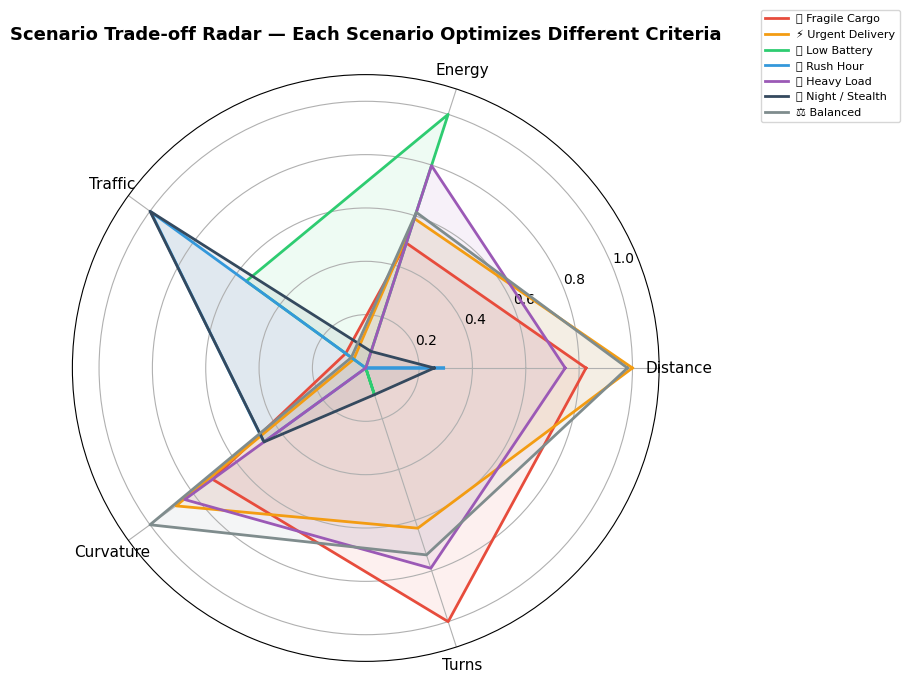

✓ Radar chart saved → delivery_dashboard_radar.png


In [251]:
# ══════════════════════════════════════════════════════════════════
#  DASHBOARD — Radar Chart: Each Scenario's Trade-off Profile
# ══════════════════════════════════════════════════════════════════

cat_labels = ["Distance", "Energy", "Traffic", "Curvature", "Turns"]
angles_r = np.linspace(0, 2 * np.pi, len(cat_labels), endpoint=False).tolist()
angles_r += angles_r[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))

# collect raw values for normalization
all_vals = {k: [] for k in ["distance", "energy", "traffic", "curvature", "turns"]}
for sname in scenario_names:
    if sname in scenario_results:
        b = scenario_results[sname]["breakdown"]
        for k in all_vals:
            all_vals[k].append(b[k])

# normalize: 1 = best (lowest), 0 = worst (highest)
ranges = {}
for k in all_vals:
    lo, hi = min(all_vals[k]), max(all_vals[k])
    ranges[k] = (lo, hi)

for sname in scenario_names:
    if sname not in scenario_results:
        continue
    b = scenario_results[sname]["breakdown"]
    vals = []
    for k in ["distance", "energy", "traffic", "curvature", "turns"]:
        lo, hi = ranges[k]
        if hi > lo:
            vals.append(1.0 - (b[k] - lo) / (hi - lo))  # 1 = best
        else:
            vals.append(1.0)
    vals += vals[:1]

    ax.plot(angles_r, vals, linewidth=2, label=f"{SCENARIOS[sname]['icon']} {sname}",
            color=SCENARIOS[sname]["color"])
    ax.fill(angles_r, vals, alpha=0.08, color=SCENARIOS[sname]["color"])

ax.set_xticks(angles_r[:-1])
ax.set_xticklabels(cat_labels, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_title("Scenario Trade-off Radar — Each Scenario Optimizes Different Criteria",
             fontsize=13, fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.42, 1.12), fontsize=8)
plt.tight_layout()
plt.savefig("delivery_dashboard_radar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Radar chart saved → delivery_dashboard_radar.png")

C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\1015052510.py:54: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\1015052510.py:54: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\1015052510.py:54: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\1015052510.py:54: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\1015052510.py:54: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\1015052510.py:55: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig("deliver

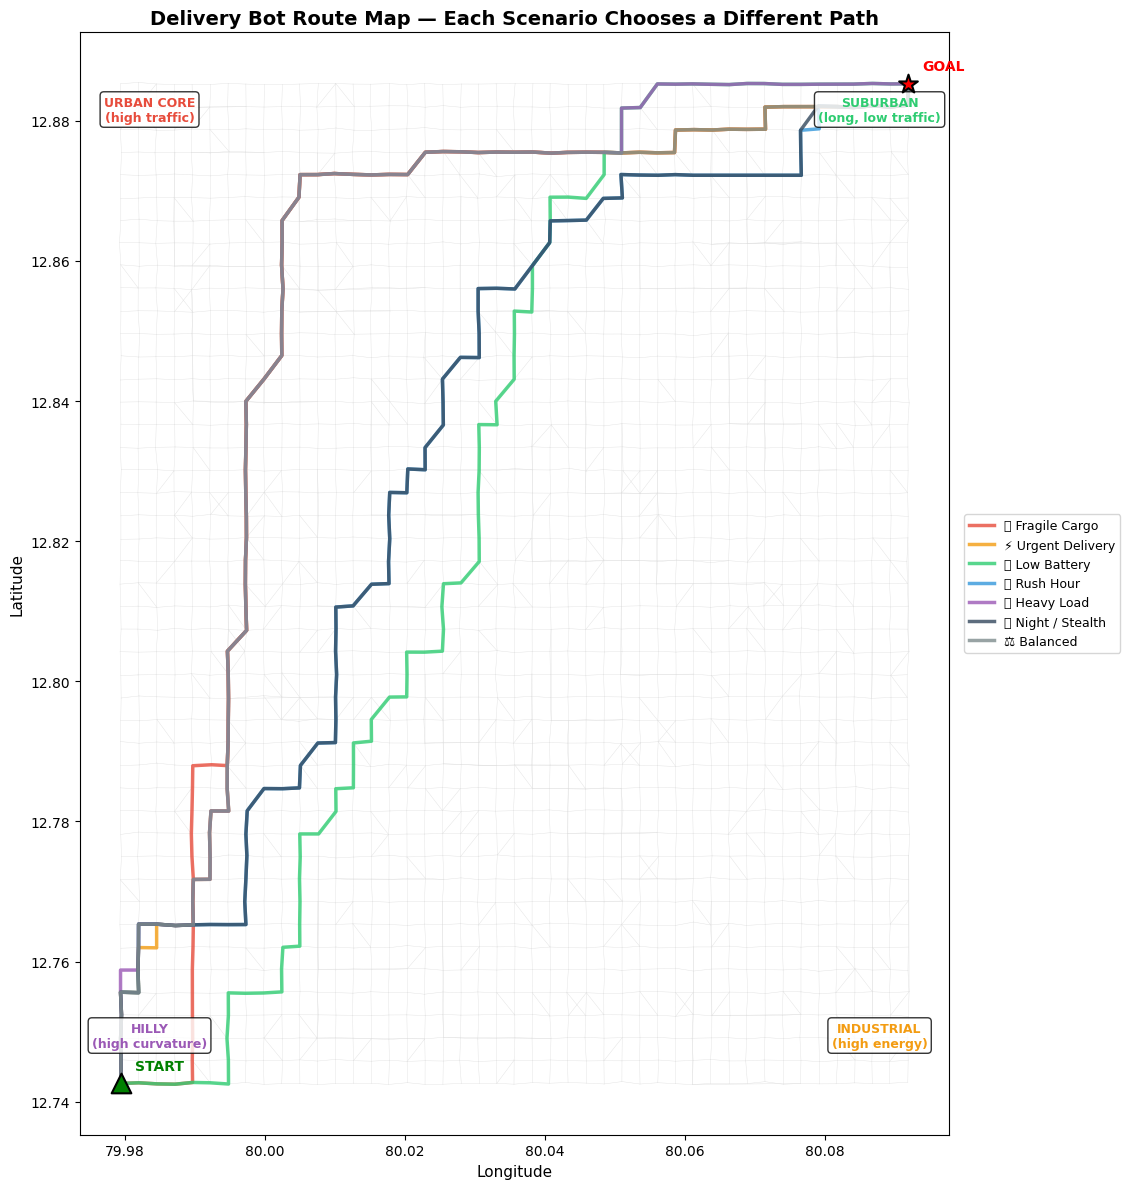

✓ Route map saved → delivery_dashboard_map.png


In [252]:
# ══════════════════════════════════════════════════════════════════
#  DASHBOARD — Spatial Path Map: Visualize routes on the grid
# ══════════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(12, 12))

# draw all edges in light gray
for u_e, v_e in G.edges():
    x0, y0 = G.nodes[u_e]["x"], G.nodes[u_e]["y"]
    x1, y1 = G.nodes[v_e]["x"], G.nodes[v_e]["y"]
    ax.plot([x0, x1], [y0, y1], color="#e0e0e0", linewidth=0.3, zorder=1)

# draw each scenario's path
for sname in scenario_names:
    if sname not in scenario_results:
        continue
    p = scenario_results[sname]["path"]
    xs_p = [G.nodes[n]["x"] for n in p]
    ys_p = [G.nodes[n]["y"] for n in p]
    ax.plot(xs_p, ys_p, color=SCENARIOS[sname]["color"],
            linewidth=2.5, alpha=0.8, label=f"{SCENARIOS[sname]['icon']} {sname}",
            zorder=2)

# mark start and goal
sx, sy = G.nodes[start_node]["x"], G.nodes[start_node]["y"]
gx, gy = G.nodes[goal_node]["x"], G.nodes[goal_node]["y"]
ax.scatter([sx], [sy], s=200, c="green", marker="^", zorder=5, edgecolors="black", linewidth=1.5)
ax.scatter([gx], [gy], s=200, c="red", marker="*", zorder=5, edgecolors="black", linewidth=1.5)
ax.annotate("START", (sx, sy), textcoords="offset points", xytext=(10, 10),
            fontsize=10, fontweight="bold", color="green")
ax.annotate("GOAL", (gx, gy), textcoords="offset points", xytext=(10, 10),
            fontsize=10, fontweight="bold", color="red")

# zone labels
ax.text(0.08, 0.92, "URBAN CORE\n(high traffic)", transform=ax.transAxes,
        fontsize=9, color="#e74c3c", fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.text(0.92, 0.92, "SUBURBAN\n(long, low traffic)", transform=ax.transAxes,
        fontsize=9, color="#2ecc71", fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.text(0.08, 0.08, "HILLY\n(high curvature)", transform=ax.transAxes,
        fontsize=9, color="#9b59b6", fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
ax.text(0.92, 0.08, "INDUSTRIAL\n(high energy)", transform=ax.transAxes,
        fontsize=9, color="#f39c12", fontweight="bold", ha="center",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

ax.set_title("Delivery Bot Route Map — Each Scenario Chooses a Different Path",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Longitude", fontsize=11)
ax.set_ylabel("Latitude", fontsize=11)
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=9)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("delivery_dashboard_map.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ Route map saved → delivery_dashboard_map.png")

C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2380541435.py:50: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2380541435.py:50: UserWarning: Glyph 128267 (\N{BATTERY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2380541435.py:50: UserWarning: Glyph 128663 (\N{AUTOMOBILE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2380541435.py:50: UserWarning: Glyph 127947 (\N{WEIGHT LIFTER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2380541435.py:50: UserWarning: Glyph 127769 (\N{CRESCENT MOON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\Akshay\AppData\Local\Temp\ipykernel_15684\2380541435.py:51: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig("deliver

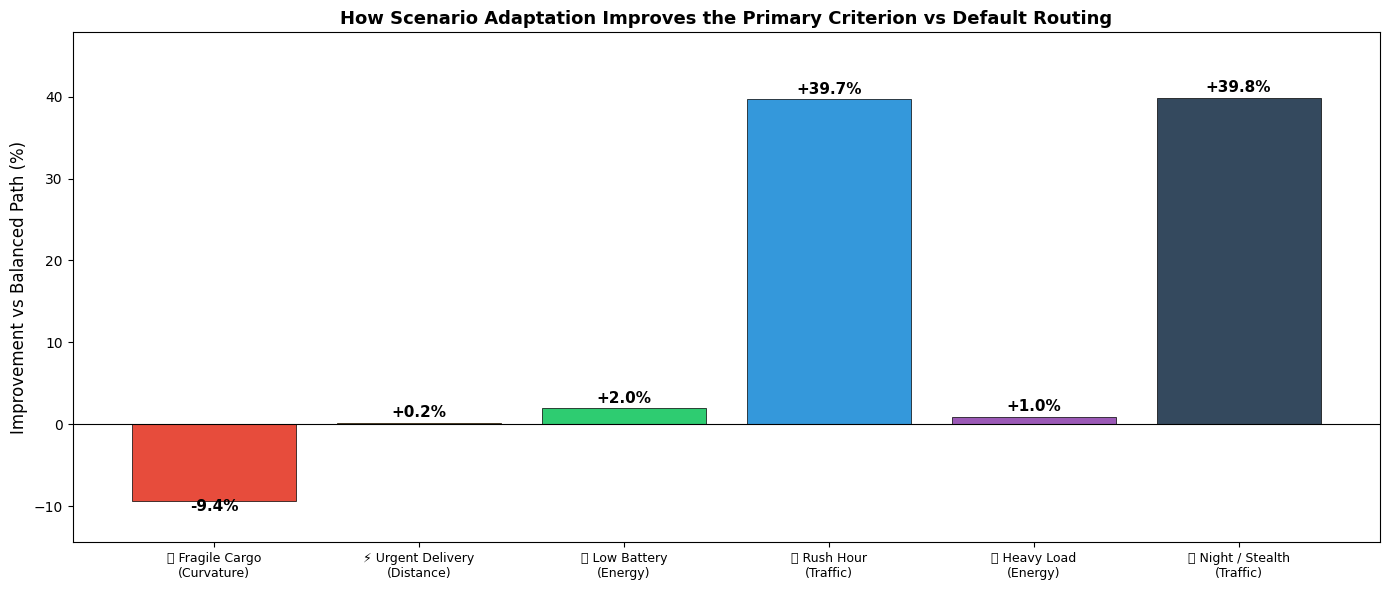

✓ Improvement chart saved → delivery_dashboard_improvement.png

  This demonstrates that AMCS produces DIFFERENT optimal paths
  depending on real-time conditions — a capability that fixed-weight
  algorithms like Dijkstra and A* cannot provide without manual tuning.


In [253]:
# ══════════════════════════════════════════════════════════════════
#  DASHBOARD — Improvement vs Balanced: How Adaptation Helps
# ══════════════════════════════════════════════════════════════════
# Compare each scenario's PRIMARY criterion against the balanced path.

balanced_b = scenario_results["Balanced"]["breakdown"]

primary_criterion = {
    "Fragile Cargo":    ("curvature",  "Curvature"),
    "Urgent Delivery":  ("distance",   "Distance"),
    "Low Battery":      ("energy",     "Energy"),
    "Rush Hour":        ("traffic",    "Traffic"),
    "Heavy Load":       ("energy",     "Energy"),
    "Night / Stealth":  ("traffic",    "Traffic"),
}

fig, ax = plt.subplots(figsize=(14, 6))

names_imp = []
improvements = []
colors_imp = []

for sname, (key, label) in primary_criterion.items():
    if sname not in scenario_results:
        continue
    b = scenario_results[sname]["breakdown"]
    bal_val = balanced_b[key]
    scen_val = b[key]
    if bal_val > 0:
        pct = (bal_val - scen_val) / bal_val * 100
    else:
        pct = 0
    names_imp.append(f"{SCENARIOS[sname]['icon']} {sname}\n({label})")
    improvements.append(pct)
    colors_imp.append(SCENARIOS[sname]["color"])

bars = ax.bar(names_imp, improvements, color=colors_imp, edgecolor="black", linewidth=0.5)

for bar, val in zip(bars, improvements):
    ypos = bar.get_height() + 0.3 if bar.get_height() >= 0 else bar.get_height() - 1.5
    ax.text(bar.get_x() + bar.get_width() / 2, ypos,
            f"{val:+.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("Improvement vs Balanced Path (%)", fontsize=12)
ax.set_title("How Scenario Adaptation Improves the Primary Criterion vs Default Routing",
             fontsize=13, fontweight="bold")
ax.set_ylim(min(improvements) - 5, max(improvements) + 8)
plt.xticks(fontsize=9)
plt.tight_layout()
plt.savefig("delivery_dashboard_improvement.png", dpi=150, bbox_inches="tight")
plt.show()

print("✓ Improvement chart saved → delivery_dashboard_improvement.png")
print("\n  This demonstrates that AMCS produces DIFFERENT optimal paths")
print("  depending on real-time conditions — a capability that fixed-weight")
print("  algorithms like Dijkstra and A* cannot provide without manual tuning.")